In [1]:
#activate venv: 

import pandas as pd
import time
#other requirements: sklearn, matplotlib, statsmodels

In [2]:
start=time.perf_counter()

In [3]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings
from FPLRunningAveragesCalculator import FPLRunningAveragesCalculator

current_season = 20252026
current_gw = 30 #predictions from gw+1

start=time.perf_counter()

if __name__ == "__main__":
    #Run Database Creator
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

    # Initialize the calculator
    calculator = FPLRunningAveragesCalculator(db_creator)
    
    # Define metrics to average
    metrics = [
        'minutes', 'total_points', 'team_elo', 'opp_team_elo',
        'goals_scored', 'bonus', 'bps', 'clean_sheets', 'goals_conceded',
        'expected_goals', 'expected_assists', 'expected_goal_involvements',
        'expected_goals_conceded', 'cbi', 'defensive_contribution',
        'recoveries', 'tackles', 'saves'
    ]
    
    # Define interaction pairs
    interaction_pairs = [
        ('expected_goal_involvements', 'defensive_contribution'),
    ]
    
    # Calculate running averages
    df = calculator.calculate(
        metrics_to_average=metrics,
        window_sizes=[3, 5, 10],
        include_alltime=True,
        include_per_90=True,
        include_raw=True,
        include_elo_adjusted=True,
        include_squared_per_90=True,
        interaction_pairs=interaction_pairs
    )

    # Identify columns to exclude from forward filling (all fpl playergwdf columns) real life data columns
    exclude_cols = ['player_name_id', 'season', 'event',
                    'fixture', 'total_points', 'minutes',
                    'goals_scored', 'assists', 'team_elo', 'opp_team_elo',
                    'position', 'bonus', 'bps', 'clean_sheets',
                    'goals_conceded', 'was_home', 'expected_assists',
                    'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded',
                    'starts', 'team_name', 'opp_team_name',
                    'cbi','defensive_contribution','recoveries','tackles'
                    'saves']

    # Create a mask for rows to fill: season 20252026 and event > 10
    mask = (df['season'] == current_season) & (df['event'] > current_gw)

    # Get columns to fill
    cols_to_fill = [col for col in df.columns if col not in exclude_cols]

    # Sort by player and event to ensure proper order
    df = df.sort_values(['season', 'player_name_id', 'event'])

    # Forward fill only for the masked rows
    df_filled = df.copy()

    for col in cols_to_fill:
        # Forward fill within each player group
        df_filled.loc[mask, col] = df_filled.groupby('player_name_id')[col].ffill()[mask]

    table_name = "playergw_transformed"
    db_creator.create_staging_table_then_insert_data(table_name, data=df_filled)
    playergw_transformed = db_creator.table_to_df(table_name=table_name)
    
    finish=time.perf_counter()
    print("playergw_transformed inserted into psql")
    print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
    print(playergw_transformed.info())

playergw_transformed inserted into psql
Finished in 27.14 minute(s)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149373 entries, 0 to 149372
Columns: 431 entries, player_name_id to saves_elo_p90sq_10
dtypes: float64(426), object(5)
memory usage: 491.2+ MB
None


In [4]:
view = db_creator.run_sql("""SELECT
                        player_name_id, team_name, team_elo, season, event, opp_team_name, opp_team_elo, total_points, minutes, goals_scored
                            FROM playergw_transformed
                        WHERE season = 20252026 
                          AND event = 26 
                          AND player_name_id = 'Bukayo Saka'
                            """)
view

,player_name_id,team_name,team_elo,season,event,opp_team_name,opp_team_elo,total_points,minutes,goals_scored
0,Bukayo Saka,Arsenal,1249.67747,20252026.0,26.0,Brentford,1081.183298,1.0,20.0,0.0


In [5]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings
from FPLPredictor import FPLPredictor

cbi_defcon_cols = [
    'cbi_at',
    'cbi_p90_at',
    'cbi_3',
    'cbi_p90_3',
    'cbi_elo_3',
    'cbi_elo_p90_3',
    'cbi_5',
    'cbi_p90_5',
    'cbi_elo_5',
    'cbi_elo_p90_5',
    'cbi_10',
    'cbi_p90_10',
    'cbi_elo_10',
    'cbi_elo_p90_10',
    'defensive_cont_at',
    'defensive_cont_p90_at',
    'defensive_cont_3',
    'defensive_cont_p90_3',
    'defensive_cont_elo_3',
    'defensive_cont_elo_p90_3',
    'defensive_cont_5',
    'defensive_cont_p90_5',
    'defensive_cont_elo_5',
    'defensive_cont_elo_p90_5',
    'defensive_cont_10',
    'defensive_cont_p90_10',
    'defensive_cont_elo_10',
    'defensive_cont_elo_p90_10',
    'saves_at',
    'saves_p90_at',
    'saves_3',
    'saves_p90_3',
    'saves_elo_3',
    'saves_elo_p90_3',
    'saves_5',
    'saves_p90_5',
    'saves_elo_5',
    'saves_elo_p90_5',
    'saves_10',
    'saves_p90_10',
    'saves_elo_10',
    'saves_elo_p90_10',
    'recoveries_at',
    'recoveries_p90_at',
    'recoveries_3',
    'recoveries_p90_3',
    'recoveries_elo_3',
    'recoveries_elo_p90_3',
    'recoveries_5',
    'recoveries_p90_5',
    'recoveries_elo_5',
    'recoveries_elo_p90_5',
    'recoveries_10',
    'recoveries_p90_10',
    'recoveries_elo_10',
    'recoveries_elo_p90_10',
    'tackles_at',
    'tackles_p90_at',
    'tackles_3',
    'tackles_p90_3',
    'tackles_elo_3',
    'tackles_elo_p90_3',
    'tackles_5',
    'tackles_p90_5',
    'tackles_elo_5',
    'tackles_elo_p90_5',
    'tackles_10',
    'tackles_p90_10',
    'tackles_elo_10',
    'tackles_elo_p90_10'
]

#Run Database Creator
if __name__ == "__main__":
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

    # Load df from sql
    df = db_creator.run_sql("""SELECT *
                            FROM playergw_transformed
                            """)
    print("=" * 80)
    print("Checking NaN Summary")
    print("=" * 80)

    temp_filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)
    temp_predictor = FPLPredictor(
        data=df[temp_filtered],
        target='expected_goals_per90',
        positions={'FWD', 'MID','DEF'},
        columns_to_drop=cbi_defcon_cols
    )
    nan_summary = temp_predictor.get_nan_summary()

Checking NaN Summary

NaN Summary for 288 potential features:
Total rows: 41001

Features with NaN values:
                                       feature  nan_count  nan_pct  non_null_count
                            recoveries_p90sq_3      35532    86.66            5469
                        recoveries_elo_p90sq_3      35532    86.66            5469
                               tackles_p90sq_3      35532    86.66            5469
                           tackles_elo_p90sq_3      35532    86.66            5469
                                   cbi_p90sq_3      35532    86.66            5469
                               cbi_elo_p90sq_3      35532    86.66            5469
                        defensive_cont_p90sq_3      35532    86.66            5469
                    defensive_cont_elo_p90sq_3      35532    86.66            5469
                               tackles_p90sq_5      35484    86.54            5517
                           tackles_elo_p90sq_5      35484    86

In [6]:
df[(df['season']==current_season)
   &(df['team_name']=='Arsenal')
   &(df['event']>20)
   &(df['player_name_id']=='Bukayo Saka')
   ][['player_name_id','event','total_points','opp_team_name','xgoals_p90sq_at']].sort_values(by='event')

,player_name_id,event,total_points,opp_team_name,xgoals_p90sq_at
132385,Bukayo Saka,21.0,3.0,Liverpool,0.364410
132387,Bukayo Saka,22.0,1.0,Nott'm Forest,0.361389
132389,Bukayo Saka,23.0,2.0,Man Utd,0.359322
132391,Bukayo Saka,24.0,0.0,Leeds,0.356240
132393,Bukayo Saka,25.0,0.0,Sunderland,0.356240
132355,Bukayo Saka,26.0,1.0,Brentford,0.356240
132373,Bukayo Saka,27.0,5.0,Spurs,0.353169
132395,Bukayo Saka,28.0,2.0,Chelsea,0.353025
132396,Bukayo Saka,29.0,9.0,Brighton,0.350034
132397,Bukayo Saka,30.0,3.0,Everton,0.347214


In [7]:
# #restricts to player_name_id who have >0 minutes in that season
# #model struggles to predict higher values, so maybe cut-off points at 10, or try log(points) as a depvar
# for each indepvar: filter outliers & standardize

In [8]:
# #Optimizing hyperparameters

# filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['expected_goals']>0)

# if __name__ == "__main__":

#     print("\n" + "=" * 80)
#     print("FWD xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)
    
#     FWD_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'FWD'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300]
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     FWD_xG_predictor.fit()
#     FWD_xG_predictor.plot_cv_results()
    
#     # Get best parameters in grid format
#     FWD_params_grid = FWD_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     FWD_xG_errors = FWD_xG_predictor.get_largest_errors(return_full_data=True)

#     print("\n" + "=" * 80)
#     print("MID xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)

#     MID_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'MID'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300] # cannot be larger than sample size!
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     MID_xG_predictor.fit()
#     MID_xG_predictor.plot_cv_results()

#     # Get best parameters in grid format
#     MID_params_grid = MID_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     MID_xG_errors = MID_xG_predictor.get_largest_errors(return_full_data=True)

#     print("\n" + "=" * 80)
#     print("DEF xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)

#     DEF_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'DEF'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300]
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     DEF_xG_predictor.fit()
#     DEF_xG_predictor.plot_cv_results()

#     # Get best parameters in grid format
#     DEF_params_grid = DEF_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     DEF_xG_errors = DEF_xG_predictor.get_largest_errors(return_full_data=True)


In [9]:
# print(FWD_params_grid)
# print(MID_params_grid)
# print(DEF_params_grid)

In [10]:
FWD_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}
MID_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}
DEF_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}

In [11]:
# target=expected_goals_per90, FWD_xG_predictor
# Cleaned df size: 2450/4170

# Performing GridSearchCV hyperparameter optimization...
# Parameter grid: {'n_estimators': [200], 'max_depth': [20, 30, 50], 'min_samples_split': [500]}
# Cross-validation folds: 5
# Fitting 5 folds for each of 3 candidates, totalling 15 fits

# Best parameters found:
#   max_depth: 20
#   min_samples_split: 500
#   n_estimators: 200

# Best CV RMSE: 0.4231

# Training Set Performance:
# R² Score: 0.1823
# RMSE: 0.4056
# MAE: 0.2978

# Test Set Performance:
# R² Score: 0.1273
# RMSE: 0.4301
# MAE: 0.3197

Cleaned df size: 2545/7603

Training Set Performance:
R² Score: 0.8457
RMSE: 12.8842
MAE: 10.6744

Test Set Performance:
R² Score: 0.3419
RMSE: 26.6713
MAE: 21.9363

Top 20 Feature Importances:
                 feature  importance
               minutes_3    0.177290
    opp_team_elo_p90sq_3    0.133898
           minutes_elo_3    0.043512
    opp_team_elo_p90sq_5    0.024896
        team_elo_p90sq_3    0.012343
        team_elo_p90sq_5    0.011608
       team_elo_p90sq_at    0.010410
                elo_diff    0.009392
   clean_sheets_p90sq_at    0.008847
            opp_team_elo    0.008693
          opp_team_elo_5    0.008327
       team_elo_p90sq_10    0.008262
   opp_team_elo_p90sq_at    0.008177
   opp_team_elo_p90sq_10    0.007327
          opp_team_elo_3    0.006815
            bps_p90sq_at    0.006763
 goals_conceded_p90sq_at    0.006717
opp_team_elo_elo_p90sq_5    0.006577
         xg_over_g_ratio    0.006118
       xassists_p90sq_at    0.006054


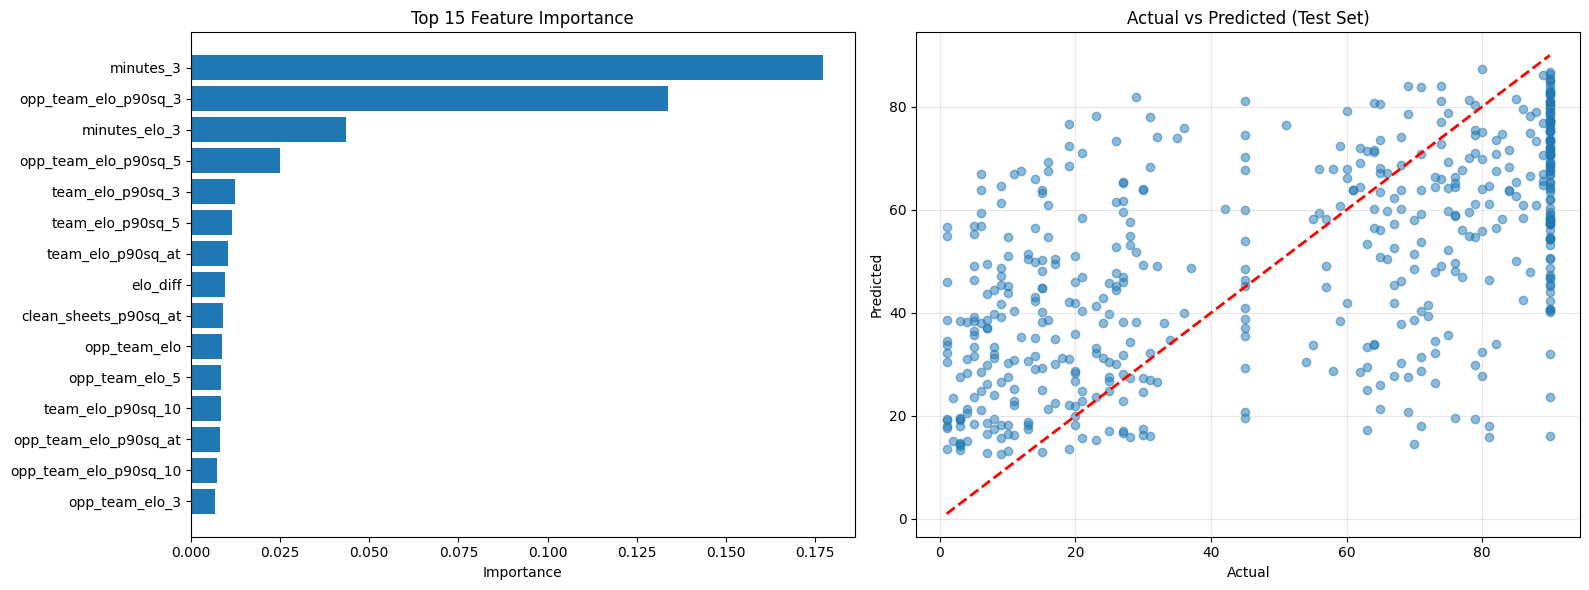

Cleaned df size: 8813/28376

Training Set Performance:
R² Score: 0.6560
RMSE: 18.7866
MAE: 15.4557

Test Set Performance:
R² Score: 0.3377
RMSE: 26.2394
MAE: 21.5096

Top 20 Feature Importances:
                 feature  importance
               minutes_3    0.378875
    opp_team_elo_p90sq_3    0.023563
   opp_team_elo_p90sq_10    0.021566
    opp_team_elo_p90sq_5    0.017492
                  bps_10    0.014923
           minutes_elo_3    0.011478
         xg_over_g_ratio    0.009128
       minutes_elo_p90_5    0.008854
              minutes_10    0.008718
       team_elo_p90sq_10    0.008046
       team_elo_p90sq_at    0.007871
            opp_team_elo    0.007190
          opp_team_elo_3    0.007084
          minutes_elo_10    0.006769
         opp_team_elo_10    0.006440
   clean_sheets_p90sq_at    0.006334
   opp_team_elo_p90sq_at    0.006079
        team_elo_p90sq_5    0.005877
          opp_team_elo_5    0.005846
xgoals_conceded_p90sq_at    0.005798


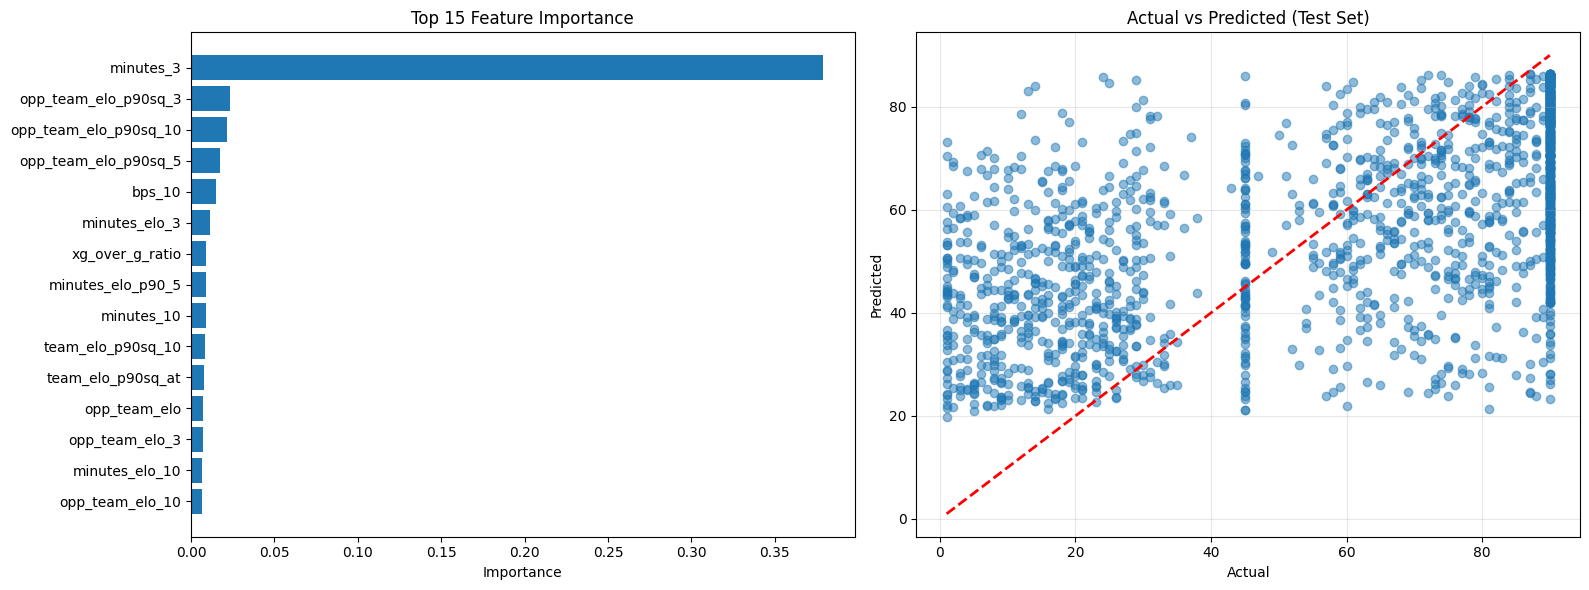

Cleaned df size: 5460/20457

Training Set Performance:
R² Score: 0.6827
RMSE: 16.5467
MAE: 12.3575

Test Set Performance:
R² Score: 0.1672
RMSE: 26.5153
MAE: 19.5940

Top 20 Feature Importances:
                 feature  importance
               minutes_3    0.135793
    opp_team_elo_p90sq_3    0.074227
        team_elo_p90sq_3    0.050182
   opp_team_elo_p90sq_10    0.023235
           minutes_elo_3    0.013653
         xg_over_g_ratio    0.012850
                elo_diff    0.010617
          opp_team_elo_3    0.010408
          opp_team_elo_5    0.010397
       xassists_p90sq_at    0.009822
         opp_team_elo_10    0.009646
 goals_conceded_p90sq_at    0.009282
opp_team_elo_elo_p90sq_3    0.009160
            opp_team_elo    0.009147
       team_elo_p90sq_10    0.009043
          bonus_p90sq_at    0.008593
xgoals_conceded_p90sq_at    0.008345
              minutes_10    0.008085
            bps_p90sq_at    0.007940
   clean_sheets_p90sq_at    0.007531


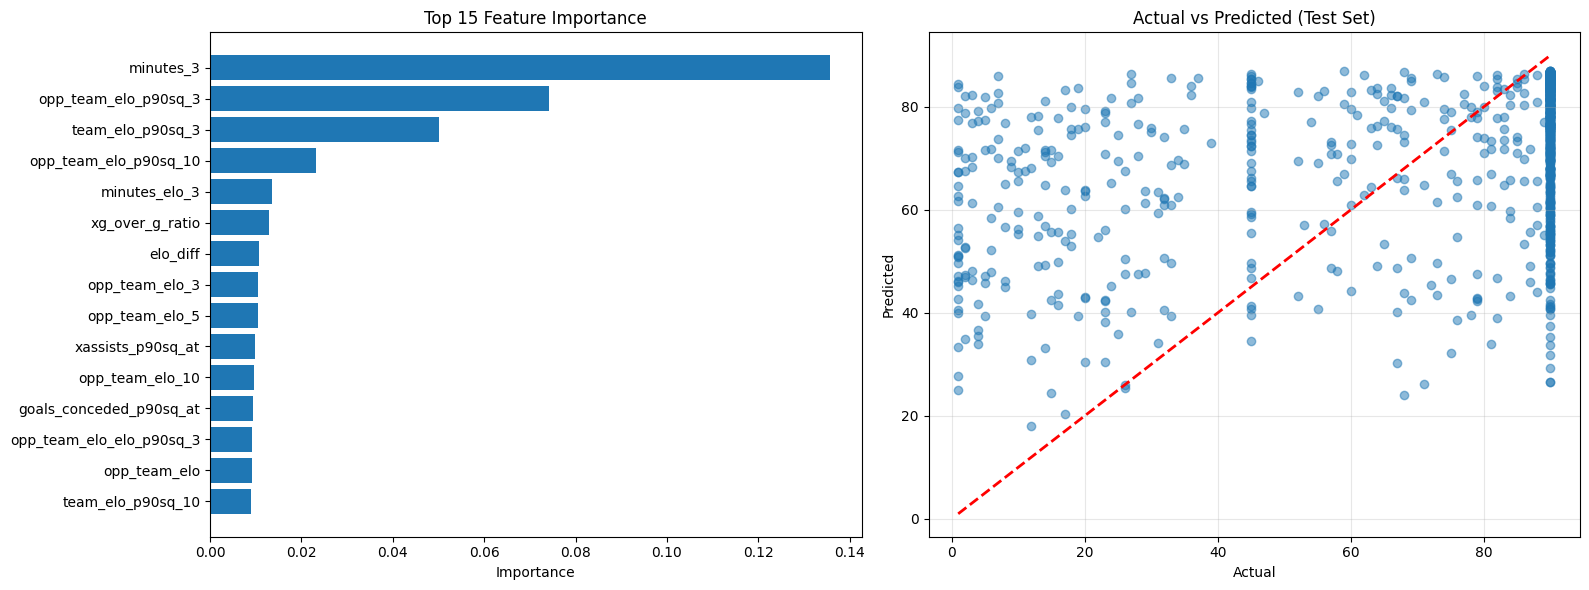

Cleaned df size: 3953/4220

Training Set Performance:
R² Score: 0.7041
RMSE: 2.7160
MAE: 0.5527

Test Set Performance:
R² Score: -0.0569
RMSE: 5.6693
MAE: 1.1592

Top 20 Feature Importances:
                    feature  importance
      opp_team_elo_p90sq_at    0.062015
               opp_team_elo    0.036185
                     bps_10    0.031626
          saves_elo_p90sq_5    0.026962
               bps_p90sq_at    0.024589
          saves_elo_p90sq_3    0.022460
             opp_team_elo_5    0.021315
               bps_p90sq_10    0.020552
             opp_team_elo_3    0.019320
                bps_p90sq_3    0.018386
          team_elo_p90sq_at    0.017573
      total_points_p90sq_10    0.016628
             saves_p90sq_10    0.015738
goals_conceded_elo_p90sq_10    0.014248
                 bps_elo_10    0.013210
                   elo_diff    0.012734
              saves_p90sq_3    0.012635
      opp_team_elo_p90sq_10    0.012434
                bps_p90sq_5    0.011968
      goa

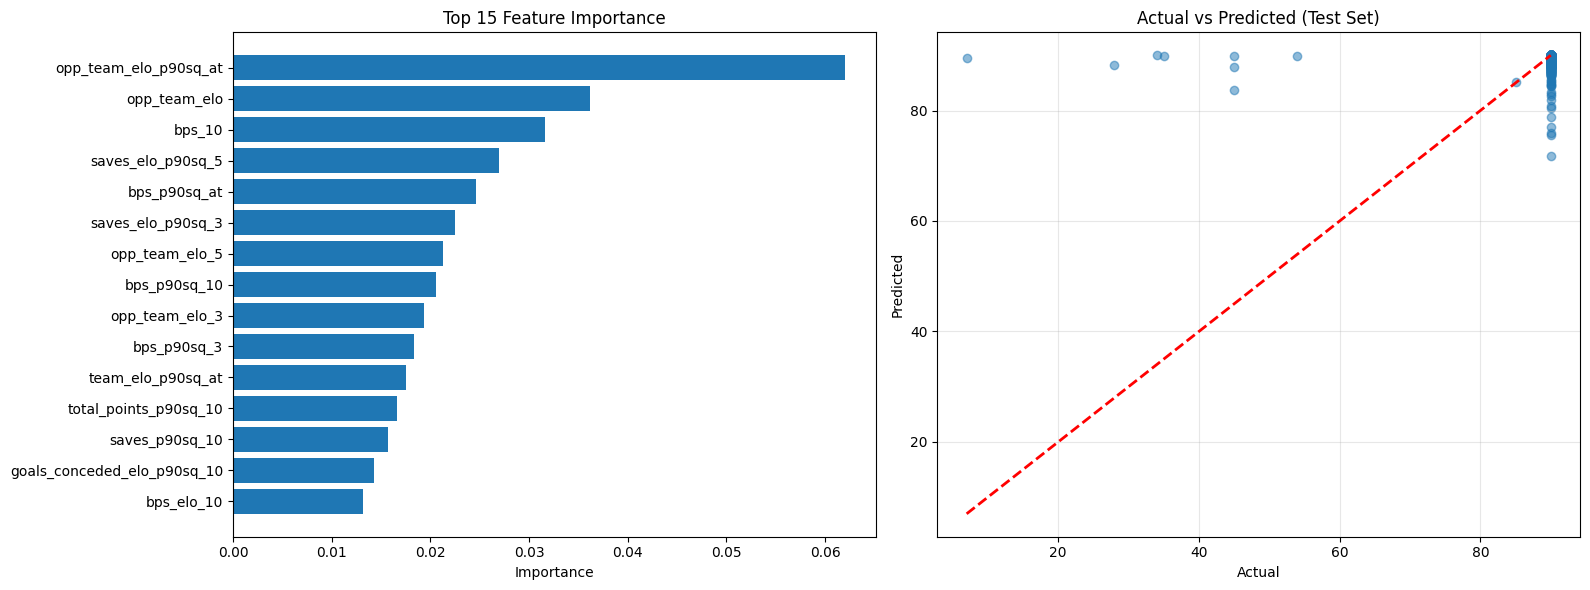

In [12]:
mins_filter = (df['player_season_minutes_total']>100)&(df['minutes']>0)

if __name__ == "__main__":
    
    FWD_mins_predictor = FPLPredictor(
                data=df[mins_filter],
        target='minutes',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=50
        )
    FWD_mins_predictor.fit()
    FWD_mins_predictor.plot_results()

    MID_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=50
        )
    MID_mins_predictor.fit()
    MID_mins_predictor.plot_results()

    DEF_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=50
        )
    DEF_mins_predictor.fit()
    DEF_mins_predictor.plot_results()

    GK_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10
        )
    GK_mins_predictor.fit()
    GK_mins_predictor.plot_results()

target=expected_goals_per90, FWD_xG_predictor
Cleaned df size: 2651/4364

Training Set Performance:
R² Score: 0.5963
RMSE: 0.2466
MAE: 0.1978

Test Set Performance:
R² Score: 0.0080
RMSE: 0.3945
MAE: 0.3004

Top 20 Feature Importances:
                  feature  importance
    goals_scored_p90sq_at    0.040433
                 elo_diff    0.034652
          xg_over_g_ratio    0.024838
           bonus_p90sq_at    0.020972
             opp_team_elo    0.018482
           opp_team_elo_5    0.016911
           opp_team_elo_3    0.016512
         team_elo_p90sq_3    0.014130
            minutes_elo_3    0.012859
          opp_team_elo_10    0.012276
     opp_team_elo_p90sq_3    0.011937
                 team_elo    0.011802
         team_elo_p90sq_5    0.011707
               team_elo_5    0.011701
  goals_conceded_p90sq_at    0.011593
        team_elo_p90sq_at    0.011169
    opp_team_elo_p90sq_10    0.010964
goals_scored_elo_p90sq_10    0.010713
    total_points_p90sq_at    0.010226
tota

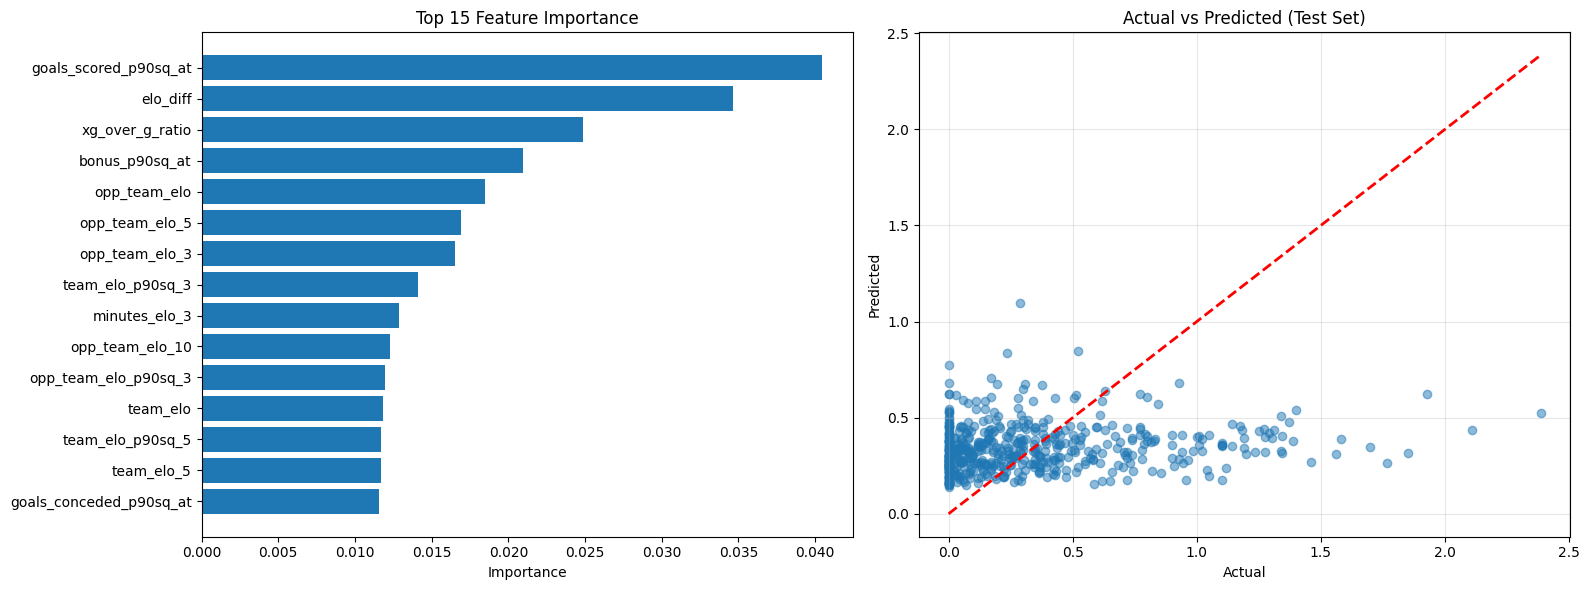

target=expected_goals_per90, MID_xG_predictor
Cleaned df size: 12228/18650

Training Set Performance:
R² Score: 0.3861
RMSE: 0.1745
MAE: 0.1176

Test Set Performance:
R² Score: 0.0716
RMSE: 0.2094
MAE: 0.1384

Top 20 Feature Importances:
                  feature  importance
    goals_scored_p90sq_at    0.151100
             opp_team_elo    0.032522
           bonus_p90sq_at    0.028191
                 elo_diff    0.020964
          opp_team_elo_10    0.019606
    clean_sheets_p90sq_at    0.016677
             bps_p90sq_10    0.015324
             bps_p90sq_at    0.013655
           opp_team_elo_3    0.012921
      total_points_elo_10    0.012652
    opp_team_elo_p90sq_at    0.011784
      goals_scored_elo_10    0.011675
        team_elo_p90sq_at    0.011224
           opp_team_elo_5    0.011197
    total_points_p90sq_at    0.010829
               bps_elo_10    0.010210
         bps_elo_p90sq_10    0.009899
    clean_sheets_p90sq_10    0.009184
total_points_elo_p90sq_10    0.009118
  

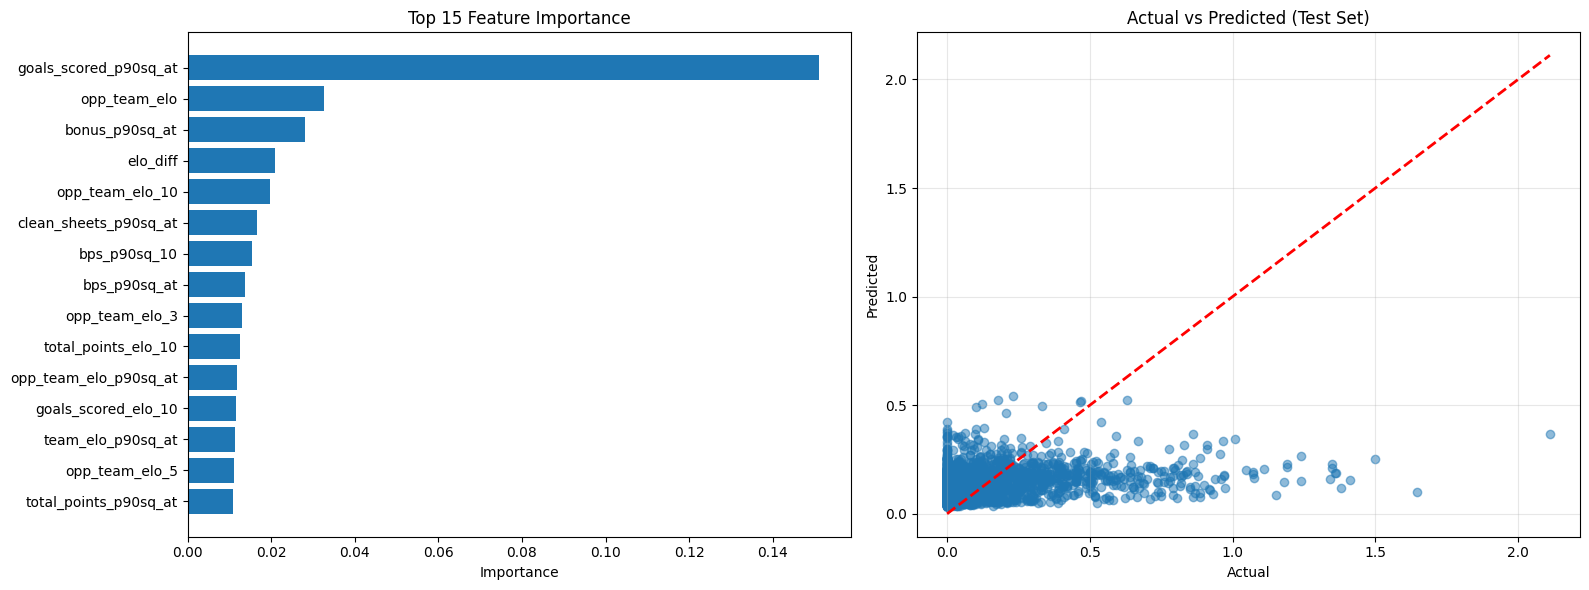

target=expected_goals_per90, DEF_xG_predictor
Cleaned df size: 10482/16690

Training Set Performance:
R² Score: 0.2678
RMSE: 0.0938
MAE: 0.0566

Test Set Performance:
R² Score: -0.0378
RMSE: 0.0949
MAE: 0.0579

Top 20 Feature Importances:
                  feature  importance
    goals_scored_p90sq_at    0.042910
             opp_team_elo    0.035881
      goals_scored_elo_10    0.024089
    goals_conceded_elo_10    0.021814
           opp_team_elo_5    0.021247
                 elo_diff    0.019054
       total_points_elo_5    0.018793
             bps_p90sq_at    0.017900
           opp_team_elo_3    0.016628
  goals_conceded_p90sq_at    0.016218
    total_points_p90sq_at    0.015747
    opp_team_elo_p90sq_10    0.015008
          opp_team_elo_10    0.014782
     opp_team_elo_p90sq_3    0.014045
  opp_team_elo_elo_p90_10    0.012858
goals_conceded_elo_p90_10    0.011116
   opp_team_elo_elo_p90_5    0.010828
        team_elo_p90sq_at    0.010506
    opp_team_elo_p90sq_at    0.010455
 

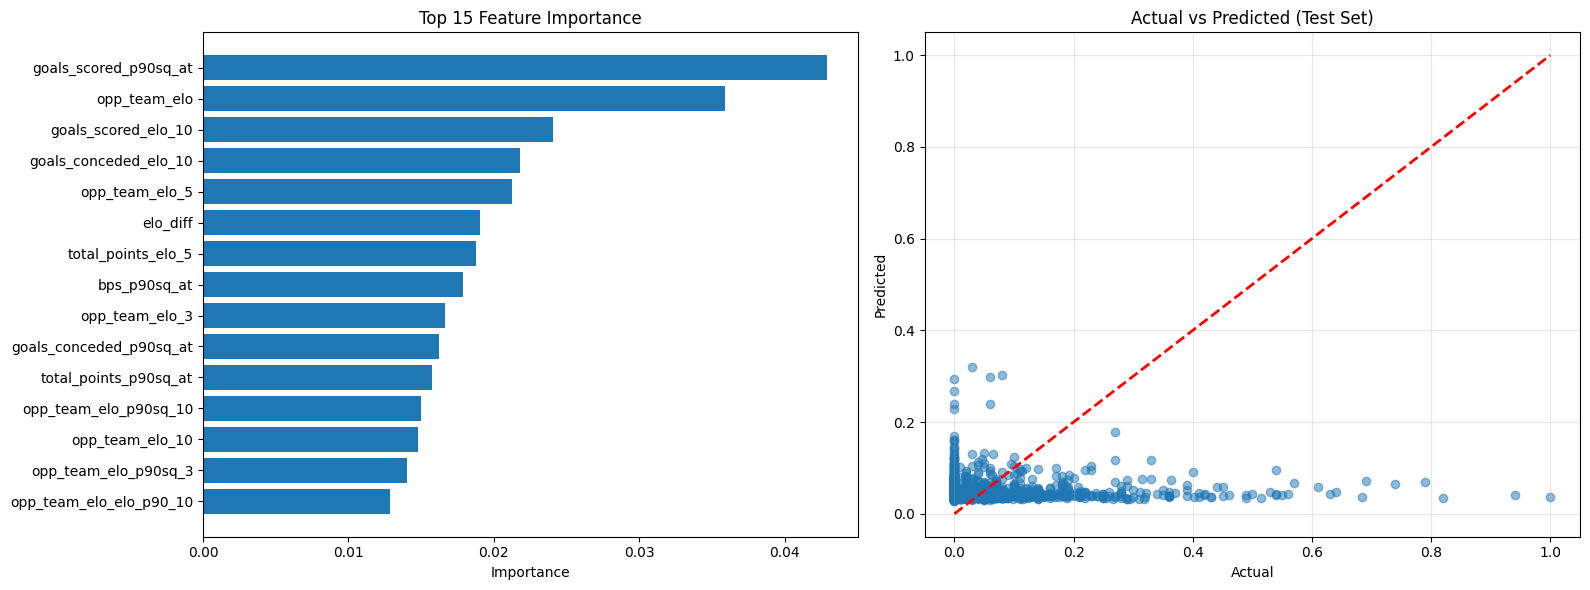

In [13]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)&(df['total_points']<12)

if __name__ == "__main__":
    
    print("target=expected_goals_per90, FWD_xG_predictor")
    FWD_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xG_predictor.fit()
    FWD_xG_predictor.plot_results()

    print("target=expected_goals_per90, MID_xG_predictor")
    MID_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xG_predictor.fit()
    MID_xG_predictor.plot_results()
    
    print("target=expected_goals_per90, DEF_xG_predictor")
    DEF_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xG_predictor.fit()
    DEF_xG_predictor.plot_results()

target=expected_assists_per90, FWD_xA_predictor
Cleaned df size: 2846/4649

Training Set Performance:
R² Score: 0.5549
RMSE: 0.0808
MAE: 0.0548

Test Set Performance:
R² Score: 0.0521
RMSE: 0.1132
MAE: 0.0720

Top 20 Feature Importances:
                 feature  importance
            opp_team_elo    0.035451
          opp_team_elo_3    0.023389
                elo_diff    0.023201
         xg_over_g_ratio    0.018058
              bps_elo_10    0.017666
     total_points_elo_10    0.016976
       minutes_elo_p90_5    0.015236
   clean_sheets_p90sq_10    0.014673
       minutes_elo_p90_3    0.014575
         opp_team_elo_10    0.013603
 goals_conceded_p90sq_at    0.013327
           minutes_elo_3    0.013154
  opp_team_elo_elo_p90_5    0.013131
      minutes_elo_p90_10    0.012861
               bps_p90_3    0.012645
   opp_team_elo_p90sq_at    0.012624
    total_points_p90sq_3    0.011986
total_points_elo_p90sq_3    0.011909
    opp_team_elo_p90sq_5    0.010929
          opp_team_elo

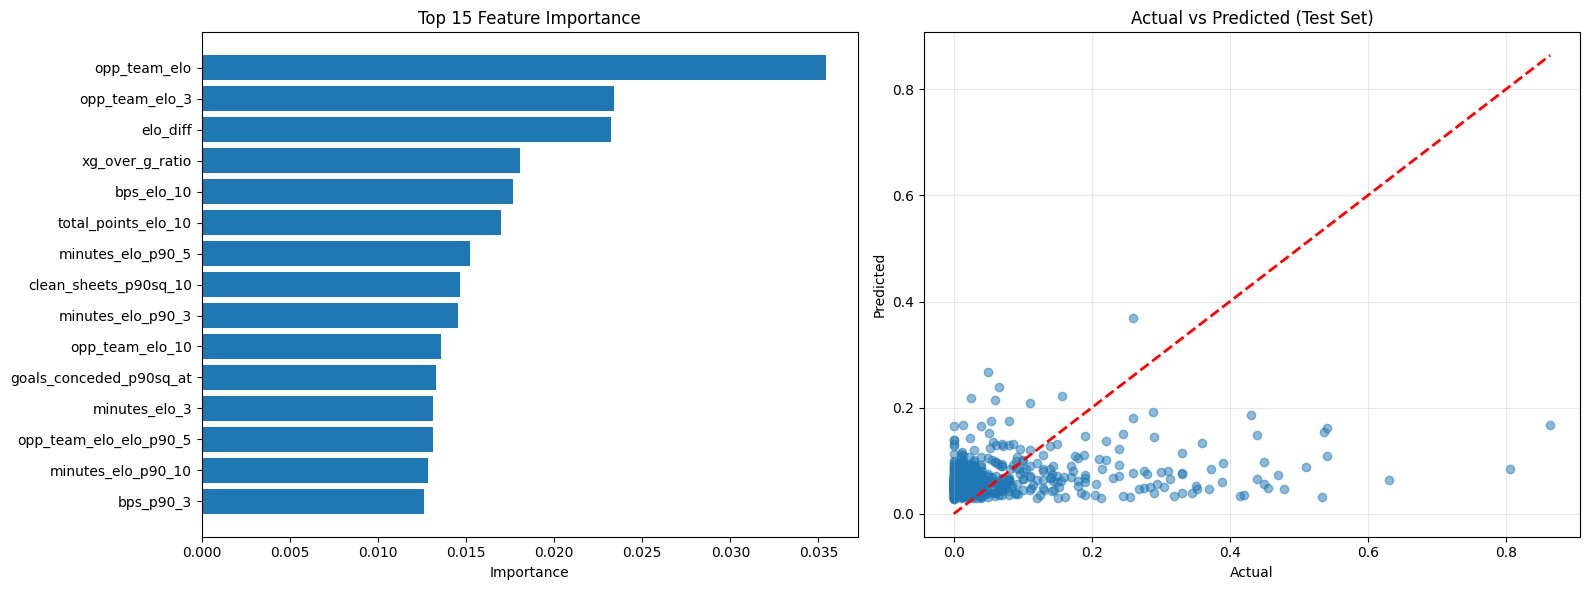

target=expected_assists_per90, MID_xA_predictor
Cleaned df size: 12661/19287

Training Set Performance:
R² Score: 0.4111
RMSE: 0.1250
MAE: 0.0889

Test Set Performance:
R² Score: 0.0750
RMSE: 0.1573
MAE: 0.1058

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.100848
         bonus_p90sq_at    0.080274
             bps_elo_10    0.027868
           opp_team_elo    0.020881
    total_points_elo_10    0.018860
  goals_scored_p90sq_at    0.017489
           bps_p90sq_at    0.016126
         opp_team_elo_5    0.015297
        opp_team_elo_10    0.014259
      team_elo_p90sq_at    0.012126
  clean_sheets_p90sq_at    0.011767
         opp_team_elo_3    0.011434
goals_conceded_p90sq_at    0.010805
  total_points_p90sq_at    0.010483
                 bps_10    0.010412
          bps_elo_p90_5    0.010010
             bps_p90_10    0.009642
        bps_elo_p90sq_5    0.009419
                  bps_5    0.008799
           bps_p90sq_10    0.008726


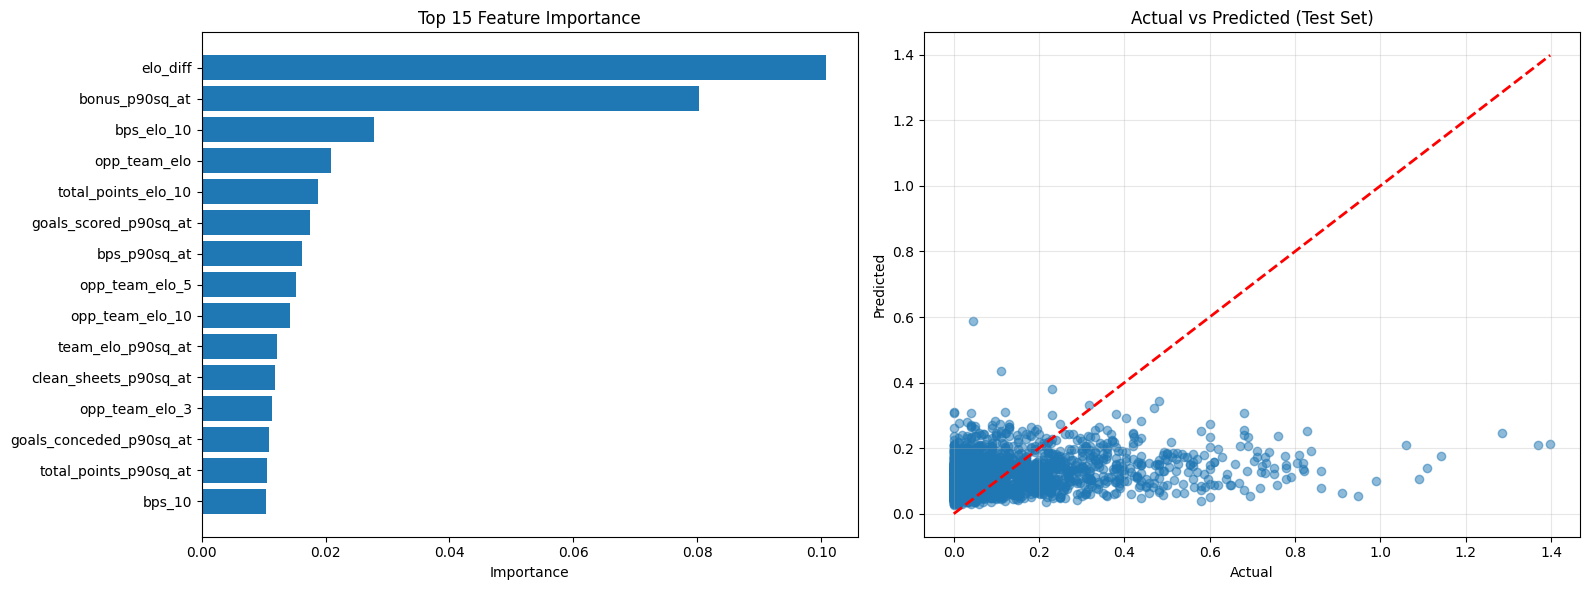

target=expected_assists_per90, DEF_xA_predictor
Cleaned df size: 10681/17014

Training Set Performance:
R² Score: 0.3799
RMSE: 0.0832
MAE: 0.0514

Test Set Performance:
R² Score: 0.0307
RMSE: 0.0983
MAE: 0.0573

Top 20 Feature Importances:
                feature  importance
         bonus_p90sq_at    0.105771
               elo_diff    0.040005
           opp_team_elo    0.028426
    minutes_elo_p90sq_3    0.022169
         opp_team_elo_3    0.017078
goals_conceded_p90sq_at    0.015306
              bps_p90_5    0.014899
        opp_team_elo_10    0.014550
               team_elo    0.014243
                  bps_3    0.014194
  clean_sheets_p90sq_at    0.013772
  goals_scored_p90sq_at    0.013302
   goals_conceded_elo_3    0.013214
      team_elo_p90sq_at    0.012851
  opp_team_elo_p90sq_at    0.012737
                 bps_10    0.012593
 opp_team_elo_elo_p90_3    0.012551
            bps_p90sq_5    0.012155
           bps_p90sq_at    0.011816
          bps_elo_p90_5    0.011654


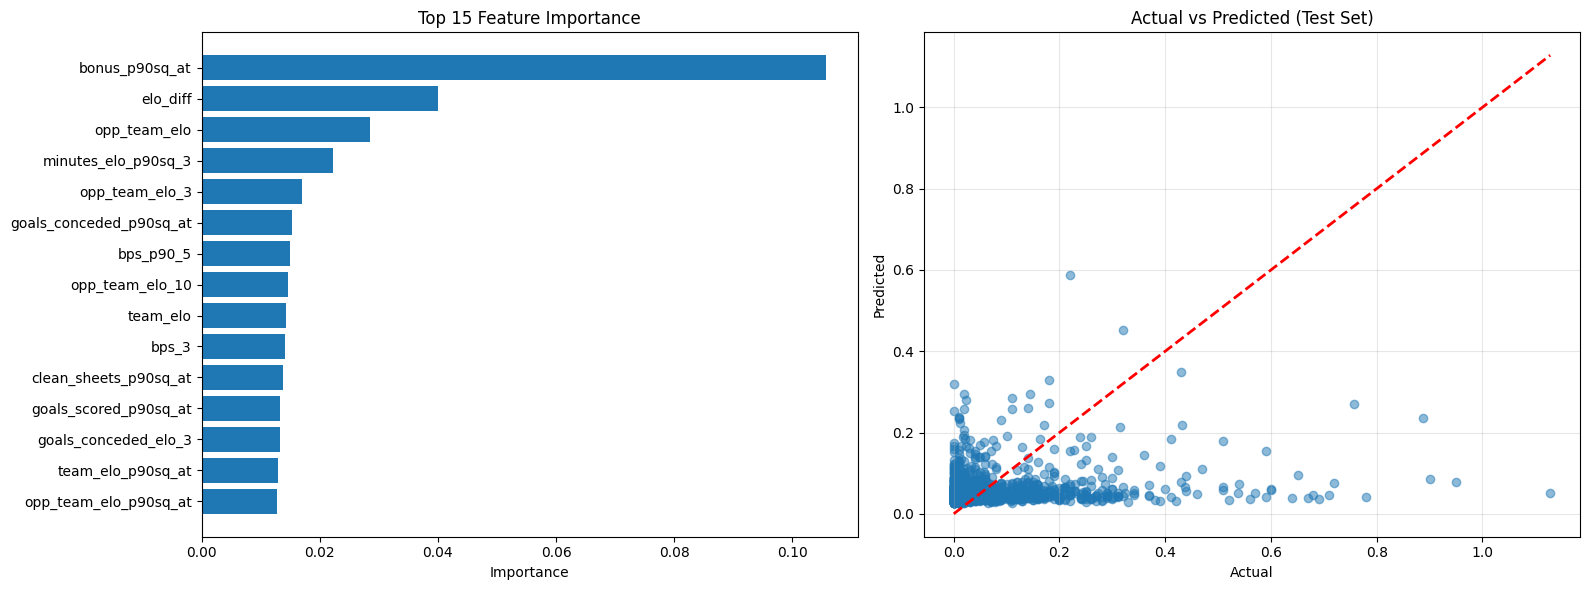

In [14]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_assists_per90, FWD_xA_predictor")
    FWD_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xA_predictor.fit()
    FWD_xA_predictor.plot_results()

    print("target=expected_assists_per90, MID_xA_predictor")
    MID_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xA_predictor.fit()
    MID_xA_predictor.plot_results()
    
    print("target=expected_assists_per90, DEF_xA_predictor")
    DEF_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xA_predictor.fit()
    DEF_xA_predictor.plot_results()

target=expected_goals_conceded_per90, FWD_xGC_predictor
Cleaned df size: 2846/4649

Training Set Performance:
R² Score: 0.6369
RMSE: 0.5529
MAE: 0.4452

Test Set Performance:
R² Score: 0.1343
RMSE: 0.8924
MAE: 0.6864

Top 20 Feature Importances:
                    feature  importance
                   elo_diff    0.167630
               opp_team_elo    0.044980
            xg_over_g_ratio    0.043687
      clean_sheets_p90sq_at    0.022149
            opp_team_elo_10    0.016359
    goals_conceded_p90sq_at    0.016231
             opp_team_elo_5    0.013554
      goals_scored_p90sq_at    0.010854
goals_conceded_elo_p90sq_10    0.010734
       goals_conceded_elo_5    0.010600
             opp_team_elo_3    0.010373
               bps_p90sq_at    0.009711
        minutes_elo_p90sq_3    0.009527
         minutes_elo_p90_10    0.009332
    goals_conceded_p90sq_10    0.009101
      total_points_p90sq_at    0.008614
      opp_team_elo_p90sq_at    0.008567
             minutes_elo_10    0.0

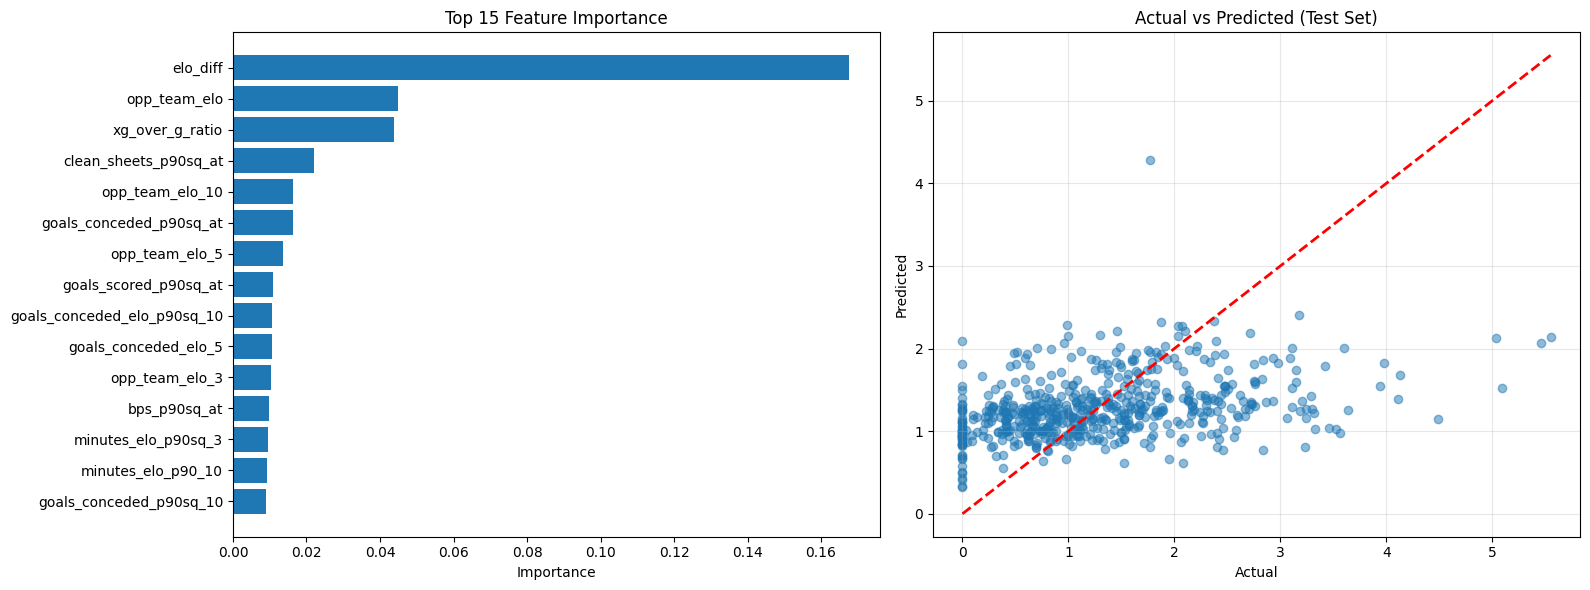

target=expected_goals_conceded_per90, MID_xGC_predictor
Cleaned df size: 12661/19287

Training Set Performance:
R² Score: 0.5494
RMSE: 0.6255
MAE: 0.4980

Test Set Performance:
R² Score: 0.3206
RMSE: 0.7679
MAE: 0.6011

Top 20 Feature Importances:
              feature  importance
             elo_diff    0.256135
         opp_team_elo    0.077916
      opp_team_elo_10    0.035707
       opp_team_elo_5    0.033581
             team_elo    0.026742
       opp_team_elo_3    0.025050
           team_elo_3    0.023315
           team_elo_5    0.022186
          team_elo_10    0.020598
   opp_team_elo_elo_3    0.020243
       team_elo_elo_3    0.018689
       team_elo_elo_5    0.015129
    minutes_elo_p90_3    0.013667
   opp_team_elo_elo_5    0.012956
  minutes_elo_p90sq_3    0.012751
      team_elo_elo_10    0.010924
  opp_team_elo_elo_10    0.010878
clean_sheets_p90sq_at    0.010791
    minutes_elo_p90_5    0.009200
 minutes_elo_p90sq_10    0.008450


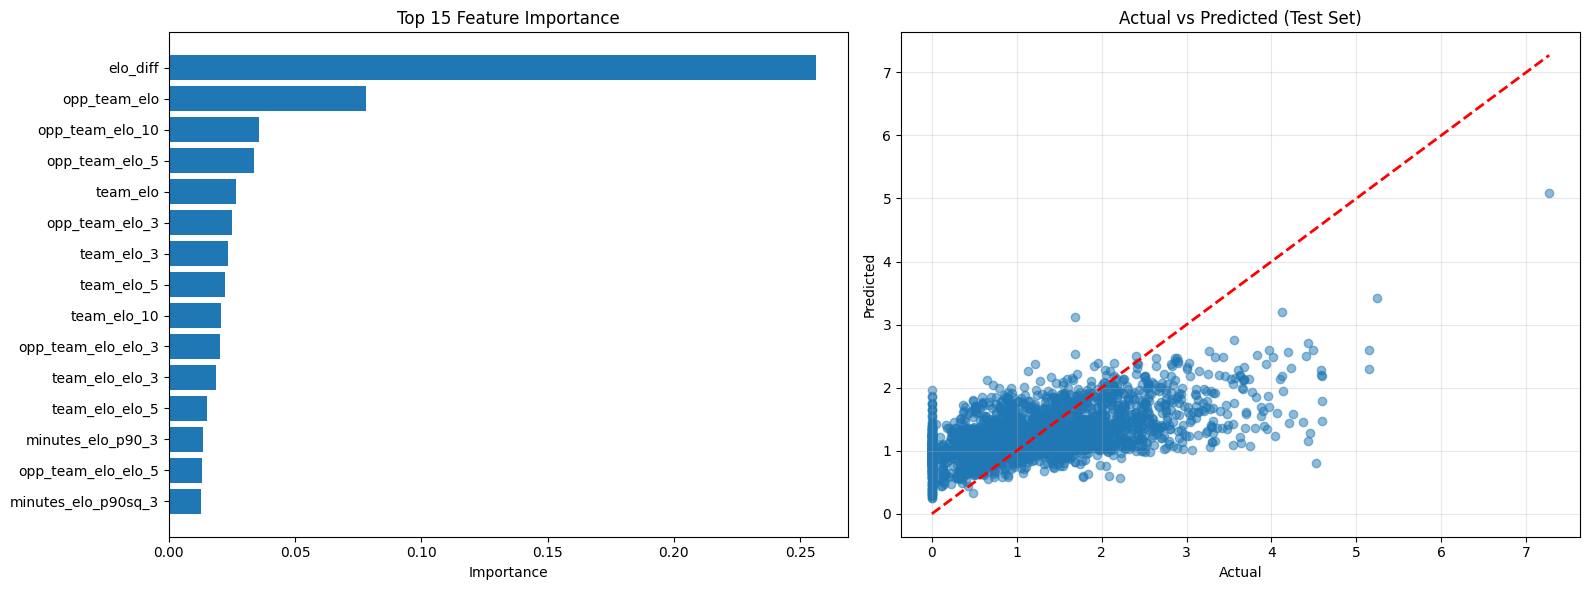

target=expected_goals_conceded_per90, DEF_xGC_predictor
Cleaned df size: 10681/17014

Training Set Performance:
R² Score: 0.5688
RMSE: 0.6111
MAE: 0.4873

Test Set Performance:
R² Score: 0.2726
RMSE: 0.7967
MAE: 0.6089

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.212338
           opp_team_elo    0.087400
        opp_team_elo_10    0.033191
         opp_team_elo_5    0.032109
    opp_team_elo_elo_10    0.029062
             team_elo_5    0.022039
            team_elo_10    0.021943
               team_elo    0.021515
         opp_team_elo_3    0.019895
             team_elo_3    0.016761
     opp_team_elo_elo_3    0.016454
  clean_sheets_p90sq_at    0.016151
goals_conceded_p90sq_at    0.015257
     opp_team_elo_elo_5    0.014191
         team_elo_elo_3    0.014094
         team_elo_elo_5    0.013105
        team_elo_elo_10    0.012237
      minutes_elo_p90_3    0.010548
  opp_team_elo_p90sq_at    0.010037
    minutes_elo_p90sq_3    0.009

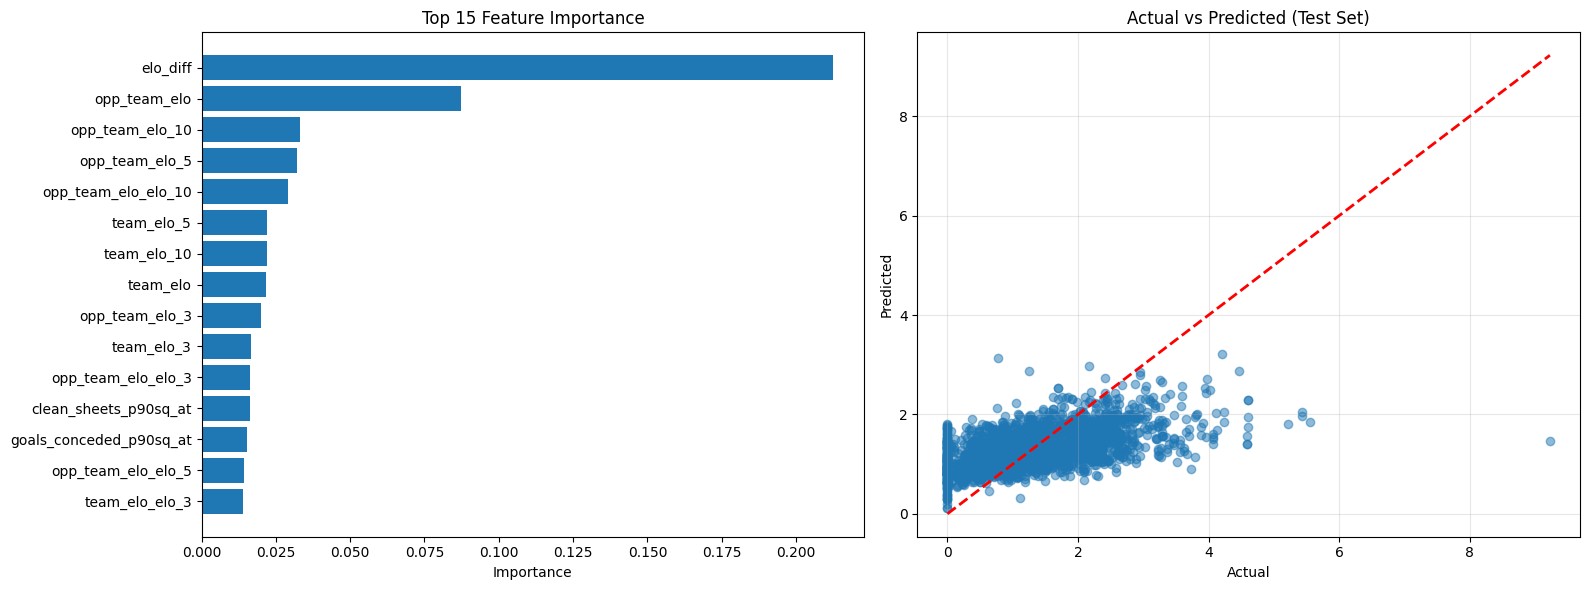

target=expected_goals_conceded_per90, GK_xGC_predictor
Cleaned df size: 2618/4158

Training Set Performance:
R² Score: 0.7039
RMSE: 0.5018
MAE: 0.4056

Test Set Performance:
R² Score: 0.1315
RMSE: 0.8310
MAE: 0.6475

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.168190
           opp_team_elo    0.044300
         saves_p90sq_at    0.035899
  opp_team_elo_p90sq_at    0.028632
  opp_team_elo_p90sq_10    0.024736
goals_conceded_p90sq_at    0.019391
        opp_team_elo_10    0.016972
     saves_elo_p90sq_10    0.016120
      team_elo_p90sq_at    0.016054
           bps_p90sq_at    0.014525
   opp_team_elo_p90sq_5    0.012915
      saves_elo_p90sq_3    0.012860
  total_points_p90sq_at    0.012498
         opp_team_elo_5    0.012371
  clean_sheets_p90sq_at    0.012196
         bonus_p90sq_at    0.012157
         saves_p90sq_10    0.010618
         opp_team_elo_3    0.009973
          saves_p90sq_5    0.009649
    minutes_elo_p90sq_3    0.009504

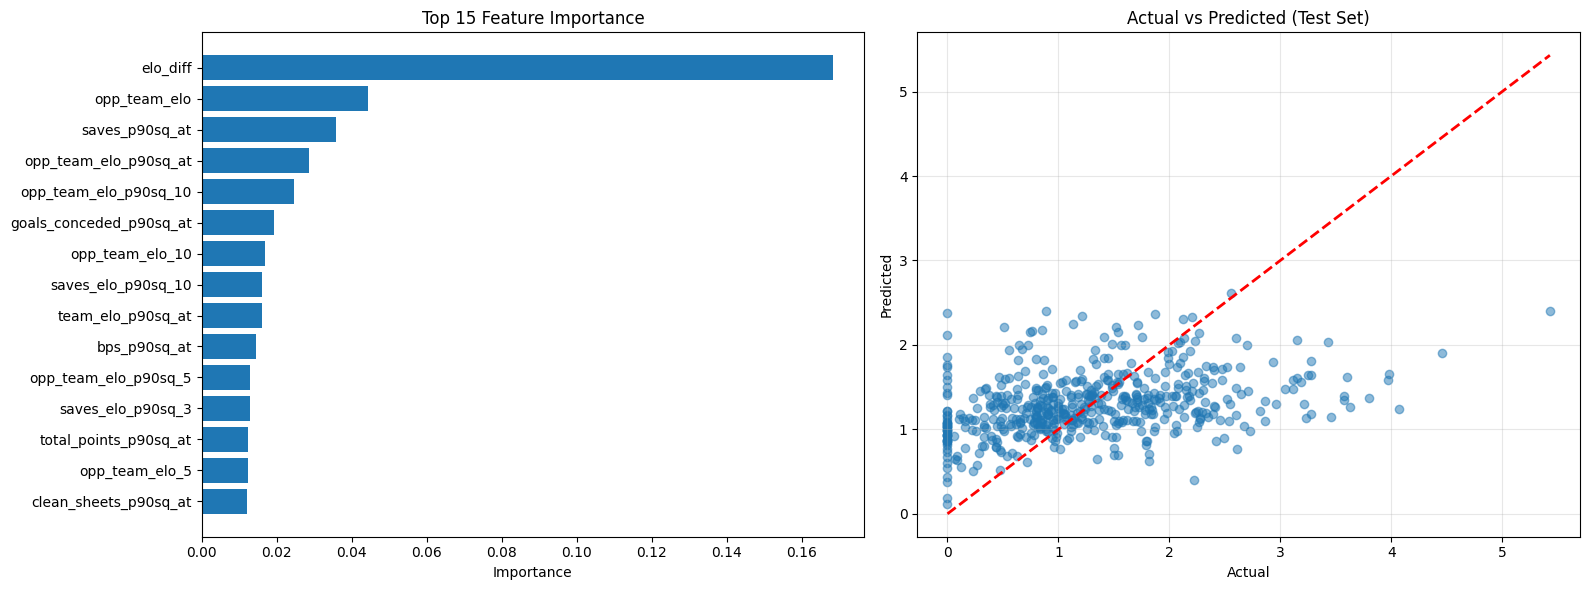

In [15]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_goals_conceded_per90, FWD_xGC_predictor")
    FWD_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xGC_predictor.fit()
    FWD_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, MID_xGC_predictor")
    MID_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xGC_predictor.fit()
    MID_xGC_predictor.plot_results()
    
    print("target=expected_goals_conceded_per90, DEF_xGC_predictor")
    DEF_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xGC_predictor.fit()
    DEF_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, GK_xGC_predictor")
    GK_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10)
    GK_xGC_predictor.fit()
    GK_xGC_predictor.plot_results()

target=bps_per90, FWD_bps_predictor
Cleaned df size: 4158/4649

Training Set Performance:
R² Score: 0.4725
RMSE: 13.4451
MAE: 10.8765

Test Set Performance:
R² Score: 0.0089
RMSE: 18.3324
MAE: 14.3611

Top 20 Feature Importances:
                  feature  importance
                 elo_diff    0.064901
             opp_team_elo    0.031775
           bonus_p90sq_at    0.020799
       opp_team_elo_elo_5    0.019791
          opp_team_elo_10    0.019058
                bps_elo_3    0.016512
           opp_team_elo_5    0.015827
  goals_conceded_p90sq_at    0.015671
        minutes_elo_p90_3    0.015226
      minutes_elo_p90sq_5    0.014054
           opp_team_elo_3    0.013983
total_points_elo_p90sq_10    0.013419
      minutes_elo_p90sq_3    0.012517
    total_points_p90sq_at    0.011623
    goals_scored_p90sq_at    0.010935
    clean_sheets_p90sq_at    0.010782
    opp_team_elo_p90sq_at    0.010705
              bps_p90sq_5    0.010152
               bps_elo_10    0.008733
          

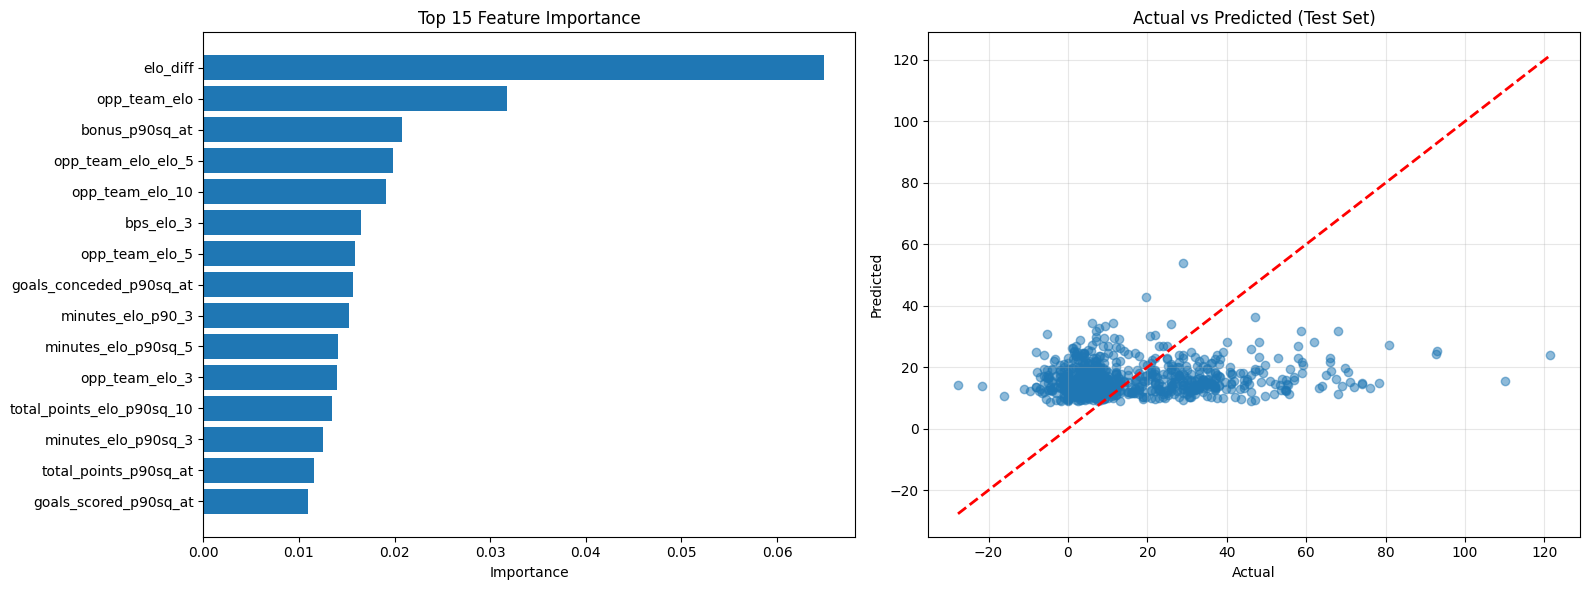

target=bps_per90, MID_bps_predictor
Cleaned df size: 18675/19287

Training Set Performance:
R² Score: 0.3177
RMSE: 9.5234
MAE: 7.2360

Test Set Performance:
R² Score: 0.0557
RMSE: 10.8479
MAE: 7.9109

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.123534
             bps_elo_10    0.040126
                 bps_10    0.035044
         bonus_p90sq_at    0.021664
           opp_team_elo    0.019607
        opp_team_elo_10    0.019294
                  bps_5    0.015733
         opp_team_elo_5    0.014485
         opp_team_elo_3    0.012450
  clean_sheets_p90sq_at    0.011522
goals_conceded_p90sq_at    0.011122
  goals_scored_p90sq_at    0.010681
      team_elo_p90sq_at    0.009848
goals_conceded_p90sq_10    0.009609
           bps_p90sq_at    0.008954
        total_points_10    0.008886
             bps_p90_10    0.008776
    total_points_elo_10    0.008731
            bps_p90sq_5    0.008667
         minutes_elo_10    0.008544


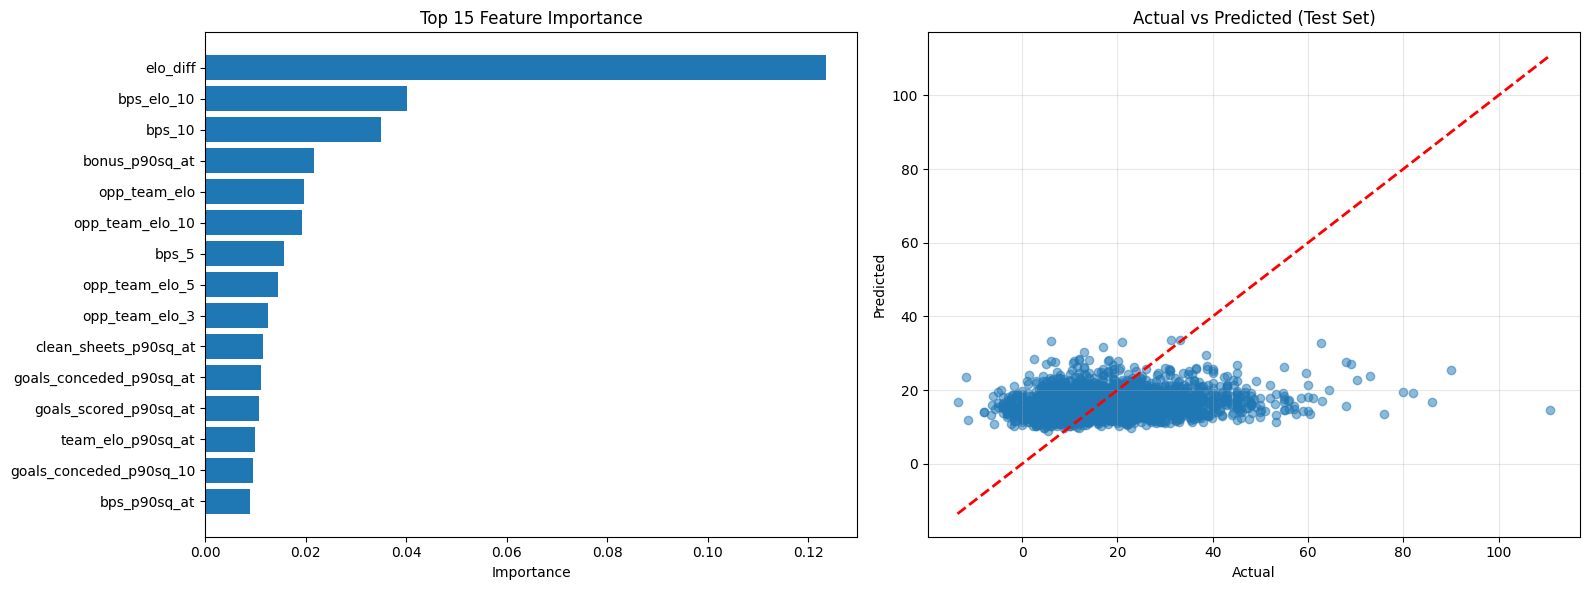

target=bps_per90, DEF_bps_predictor
Cleaned df size: 16008/17014

Training Set Performance:
R² Score: 0.4101
RMSE: 7.6612
MAE: 6.1381

Test Set Performance:
R² Score: 0.1330
RMSE: 8.9518
MAE: 7.0775

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.235131
           opp_team_elo    0.034989
        opp_team_elo_10    0.025484
         opp_team_elo_5    0.020539
         opp_team_elo_3    0.017797
         bonus_p90sq_at    0.016137
            bps_p90sq_5    0.013085
goals_conceded_p90sq_at    0.011931
            team_elo_10    0.011707
  clean_sheets_p90sq_at    0.011524
              bps_p90_5    0.010970
               team_elo    0.010715
           bps_p90sq_at    0.010163
  goals_scored_p90sq_at    0.009199
             bps_p90_10    0.009199
                 bps_10    0.008926
            bps_p90sq_3    0.008685
        bps_elo_p90sq_3    0.008402
             bps_elo_10    0.008346
        bps_elo_p90sq_5    0.008032


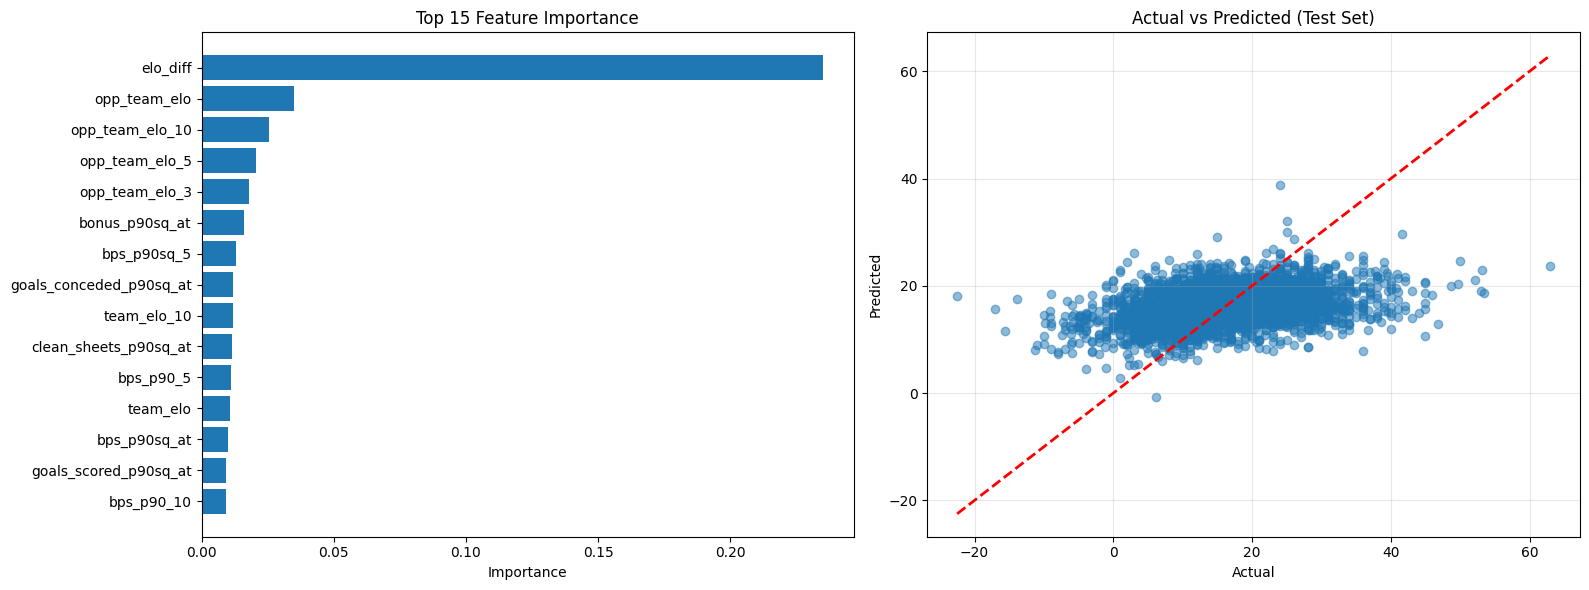

target=bps_per90, GK_bps_predictor
Cleaned df size: 3916/4158

Training Set Performance:
R² Score: 0.5295
RMSE: 6.0795
MAE: 4.9173

Test Set Performance:
R² Score: 0.0449
RMSE: 8.9424
MAE: 7.1548

Top 20 Feature Importances:
                    feature  importance
            opp_team_elo_10    0.033504
               bps_p90sq_10    0.033338
               opp_team_elo    0.029358
                 bps_p90_10    0.025241
               bps_p90sq_at    0.021870
                bps_p90sq_3    0.020343
                   elo_diff    0.019414
    goals_conceded_p90sq_at    0.017503
      opp_team_elo_p90sq_at    0.017472
          saves_elo_p90sq_3    0.017168
      total_points_p90sq_10    0.016036
             saves_p90sq_10    0.015676
           bps_elo_p90sq_10    0.015573
              saves_p90sq_5    0.015002
             saves_p90sq_at    0.014618
       opp_team_elo_p90sq_3    0.014561
             opp_team_elo_3    0.014490
             opp_team_elo_5    0.014298
       opp_team

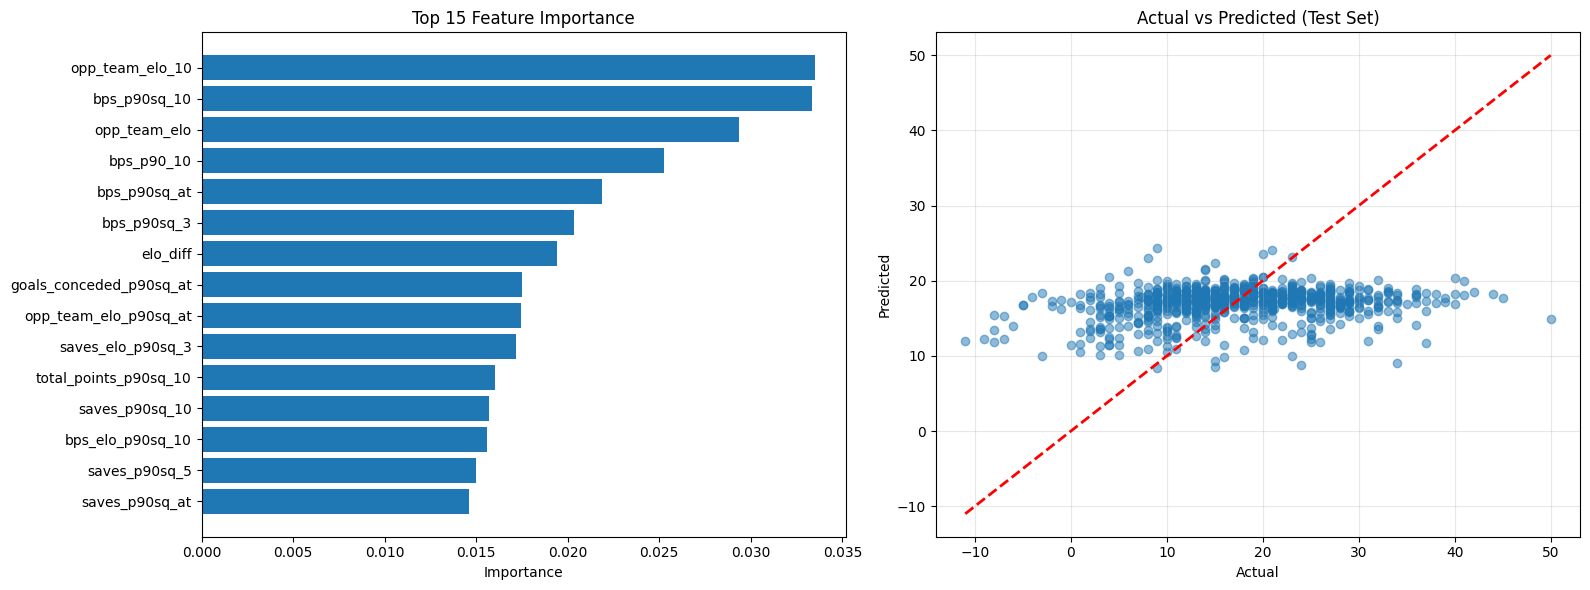

In [16]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=bps_per90, FWD_bps_predictor")
    FWD_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90', # try: 'bonus_per90'
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_bps_predictor.fit()
    FWD_bps_predictor.plot_results()

    print("target=bps_per90, MID_bps_predictor")
    MID_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_bps_predictor.fit()
    MID_bps_predictor.plot_results()
    
    print("target=bps_per90, DEF_bps_predictor")
    DEF_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_bps_predictor.fit()
    DEF_bps_predictor.plot_results()

    print("target=bps_per90, GK_bps_predictor")
    GK_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10)
    GK_bps_predictor.fit()
    GK_bps_predictor.plot_results()

target=saves_per90, GK_saves_predictor
Cleaned df size: 3916/4179

Training Set Performance:
R² Score: 0.5808
RMSE: 1.2699
MAE: 1.0228

Test Set Performance:
R² Score: 0.0257
RMSE: 1.9160
MAE: 1.5202

Top 20 Feature Importances:
                  feature  importance
                 elo_diff    0.144882
             opp_team_elo    0.025954
           saves_p90sq_at    0.022587
    opp_team_elo_p90sq_at    0.018123
           opp_team_elo_5    0.017902
          opp_team_elo_10    0.015523
  goals_conceded_p90sq_at    0.014275
           opp_team_elo_3    0.013010
             bps_p90sq_at    0.012647
       saves_elo_p90sq_10    0.012462
             bps_p90sq_10    0.011564
           bonus_p90sq_at    0.011550
        team_elo_p90sq_at    0.011436
    opp_team_elo_p90sq_10    0.011284
           saves_p90sq_10    0.010399
total_points_elo_p90sq_10    0.010361
        saves_elo_p90sq_3    0.010353
              saves_elo_3    0.010279
 total_points_elo_p90sq_5    0.010195
     opp_te

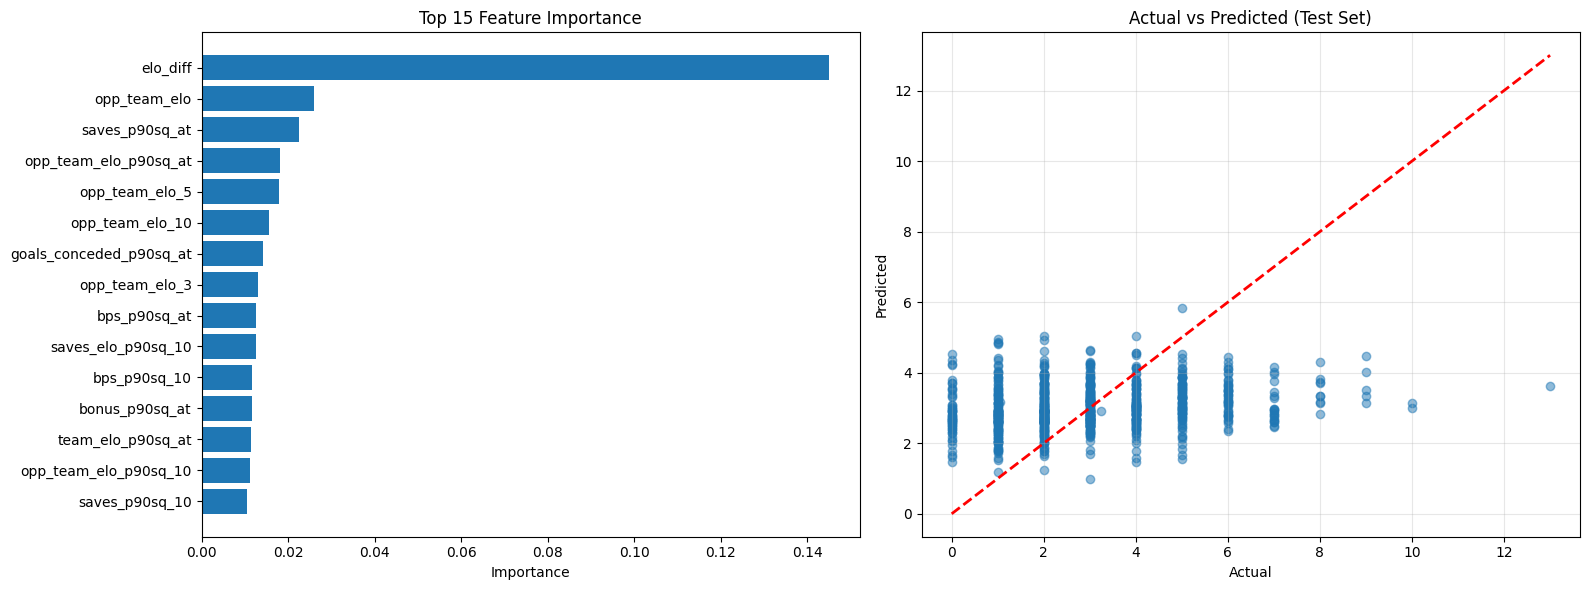

In [17]:
#shots saved
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=saves_per90, GK_saves_predictor")
    GK_saves_predictor = FPLPredictor(
        data=df[filtered],
        target='saves_per90',
        positions={'GK'},
        max_nan_pct=10)
    GK_saves_predictor.fit()
    GK_saves_predictor.plot_results()

target=defensive_contribution_per90, FWD_defcon_predictor
Cleaned df size: 652/5139

Training Set Performance:
R² Score: 0.8079
RMSE: 1.2471
MAE: 1.0049

Test Set Performance:
R² Score: -0.0643
RMSE: 2.9538
MAE: 2.2609

Top 20 Feature Importances:
                  feature  importance
          xg_over_g_ratio    0.030239
  goals_conceded_p90sq_at    0.030087
               minutes_10    0.025623
    clean_sheets_p90sq_at    0.024095
           opp_team_elo_5    0.019338
        team_elo_p90sq_10    0.017727
           bonus_p90sq_at    0.016393
opp_team_elo_elo_p90sq_10    0.015848
    goals_scored_p90sq_at    0.015576
     opp_team_elo_p90sq_5    0.015456
    goals_conceded_elo_10    0.014973
          opp_team_elo_10    0.014124
             opp_team_elo    0.013707
     goals_conceded_p90_5    0.013277
    opp_team_elo_p90sq_at    0.013152
    goals_conceded_p90_10    0.012722
             bps_p90sq_at    0.012369
           opp_team_elo_3    0.012160
 total_points_elo_p90sq_3    0

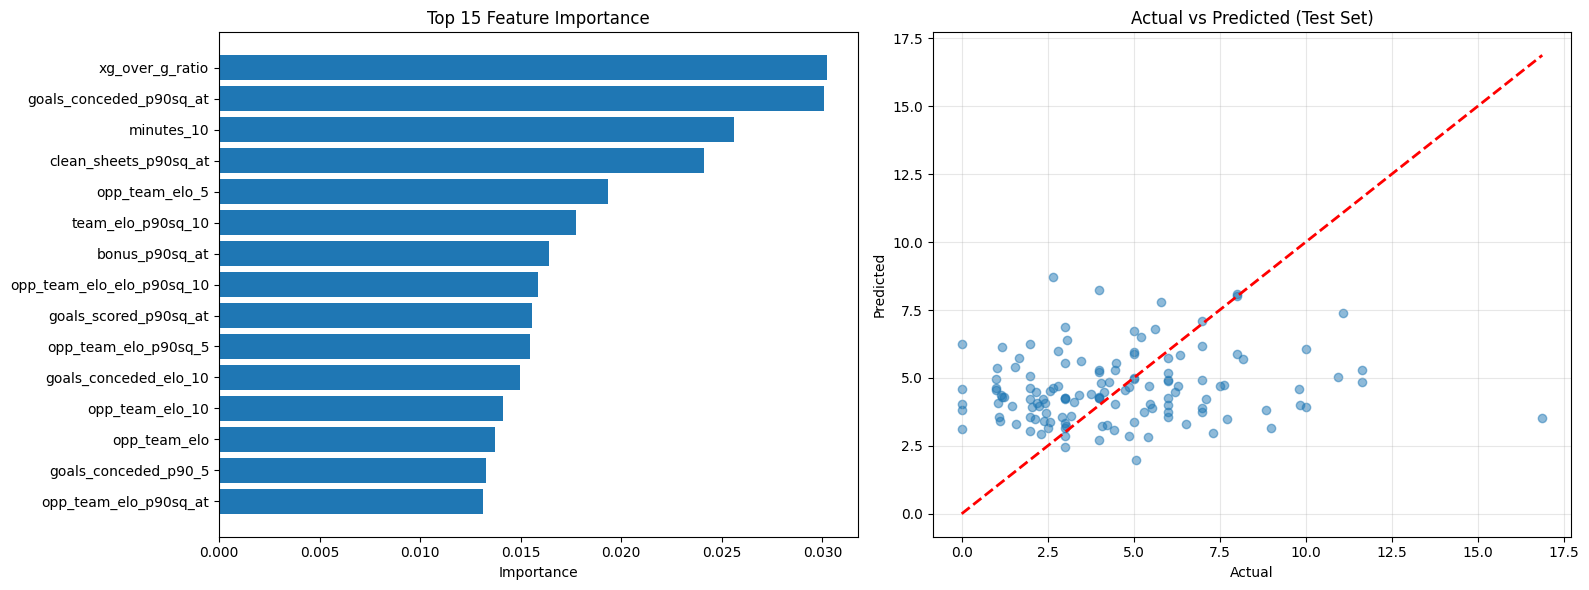

target=defensive_contribution_per90, MID_defcon_predictor
Cleaned df size: 2951/21213

Training Set Performance:
R² Score: 0.6661
RMSE: 2.4381
MAE: 1.9657

Test Set Performance:
R² Score: 0.1481
RMSE: 3.8283
MAE: 3.0669

Top 20 Feature Importances:
                    feature  importance
      goals_scored_p90sq_at    0.098012
             bonus_p90sq_at    0.038230
    goals_conceded_p90sq_at    0.033940
      total_points_p90sq_at    0.022606
      goals_conceded_elo_10    0.017800
               bps_p90sq_at    0.016065
           team_elo_p90sq_5    0.014432
               opp_team_elo    0.013292
            opp_team_elo_10    0.012642
      clean_sheets_p90sq_at    0.012408
      opp_team_elo_p90sq_at    0.012187
                   elo_diff    0.012133
goals_conceded_elo_p90sq_10    0.012081
                      bps_3    0.012020
          team_elo_p90sq_at    0.011043
             opp_team_elo_5    0.010483
  total_points_elo_p90sq_10    0.009850
         minutes_elo_p90_10    

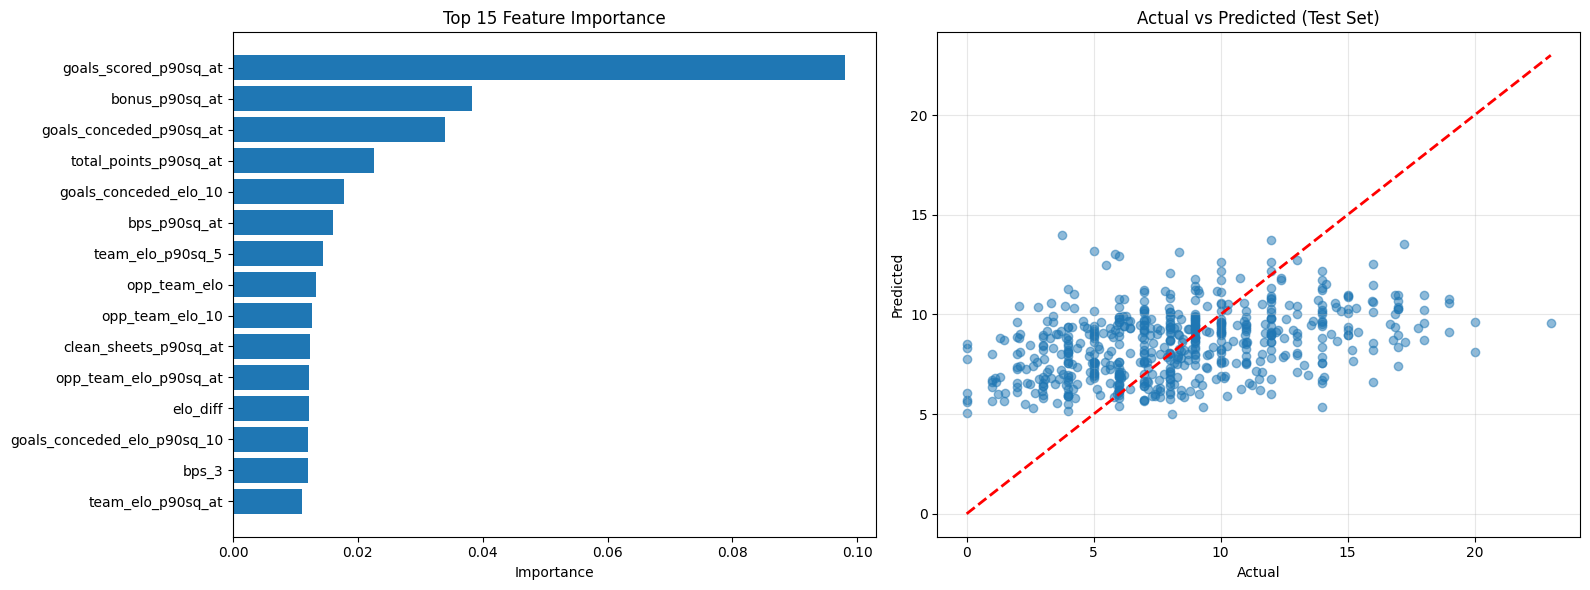

target=defensive_contribution_per90, DEF_defcon_predictor
Cleaned df size: 2470/17980

Training Set Performance:
R² Score: 0.6587
RMSE: 2.2880
MAE: 1.8446

Test Set Performance:
R² Score: 0.0905
RMSE: 3.6220
MAE: 2.8576

Top 20 Feature Importances:
                                   feature  importance
                                cbi_p90_at    0.068114
                              opp_team_elo    0.025128
                         recoveries_p90_at    0.023914
                            tackles_p90_at    0.022760
                     opp_team_elo_p90sq_at    0.022599
xgoal_involvements_x_defensive_cont_p90_at    0.022524
                     total_points_p90sq_at    0.020195
                   goals_conceded_p90sq_at    0.019301
                            bonus_p90sq_at    0.018874
                   opp_team_elo_elo_p90_10    0.017186
                                  elo_diff    0.015024
                     clean_sheets_p90sq_at    0.013356
                            opp_team

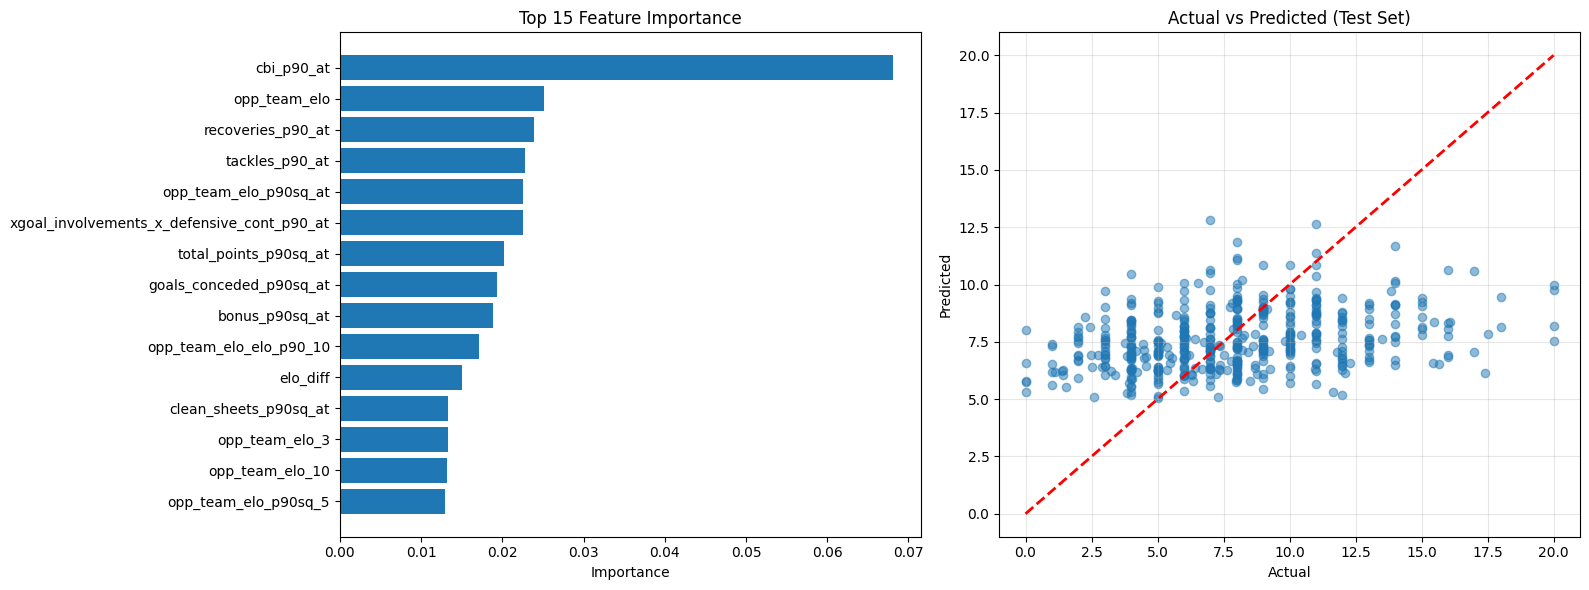

In [18]:
# >10 defcon (CBIT) for a defender
# >12 defcon (CBIT+R) for mid or fwd
filtered = (df['minutes']>30)&(df['player_season_minutes_total']>0)

if __name__ == "__main__":
    
    print("target=defensive_contribution_per90, FWD_defcon_predictor")
    FWD_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'FWD'},
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_defcon_predictor.fit()
    FWD_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, MID_defcon_predictor")
    MID_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'MID'},
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_defcon_predictor.fit()
    MID_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, DEF_defcon_predictor")
    DEF_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'DEF'},
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_defcon_predictor.fit()
    DEF_defcon_predictor.plot_results()

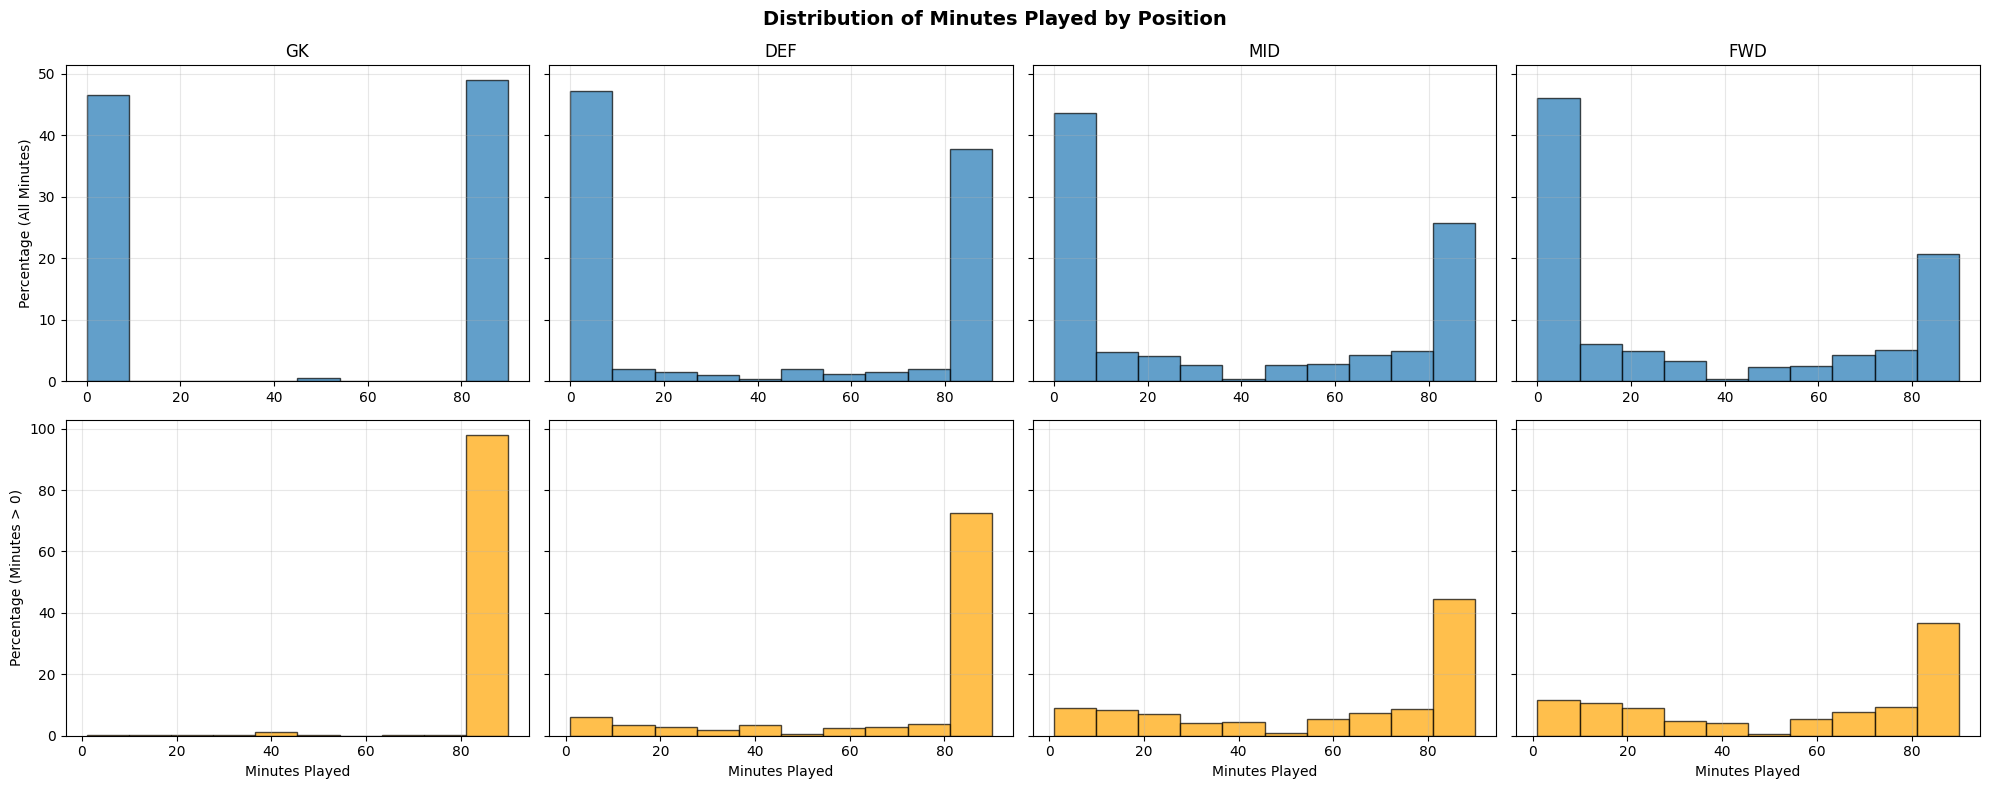

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Filter for specific positions
positions = ['GK', 'DEF', 'MID', 'FWD']
n_positions = len(positions)

# Create subplots with 2 rows
fig, axes = plt.subplots(2, n_positions, figsize=(5*n_positions, 8), sharey='row')

# Row 1: All data
for i, position in enumerate(positions):
    position_minutes = df[df['position'] == position]['minutes']
    axes[0, i].hist(position_minutes, bins=10, edgecolor='black', alpha=0.7, 
                    weights=100*np.ones(len(position_minutes))/len(position_minutes))
    axes[0, i].set_title(position)
    axes[0, i].grid(True, alpha=0.3)

axes[0, 0].set_ylabel('Percentage (All Minutes)')

# Row 2: Minutes > 0
for i, position in enumerate(positions):
    position_minutes = df[(df['position'] == position) & (df['minutes'] > 0)]['minutes']
    axes[1, i].hist(position_minutes, bins=10, edgecolor='black', alpha=0.7, color='orange',
                    weights=100*np.ones(len(position_minutes))/len(position_minutes))
    axes[1, i].set_xlabel('Minutes Played')
    axes[1, i].grid(True, alpha=0.3)

axes[1, 0].set_ylabel('Percentage (Minutes > 0)')

plt.suptitle('Distribution of Minutes Played by Position', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Goals conceded per 90
Estimated λ (mean goals per match): 1.358


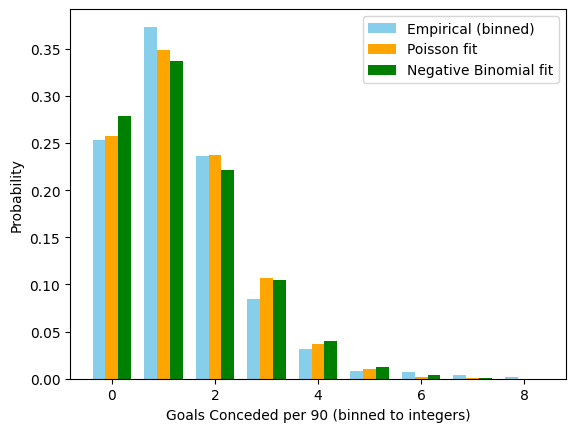

Mean: 1.349, Variance: 1.504
Overdispersion ratio (Var/Mean): 1.115
✅ Poisson assumption looks reasonable.
P(X < 1 goal) = 0.257


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Goals conceded per 90")

# Compute xGC per 90
data = df.copy()
data['xgc_p90'] = (data['expected_goals_conceded'] / data['minutes']) * 90

# Filter to reasonable samples
data = data[(data['minutes'] > 0) & (data['xgc_p90'] < 8)]['xgc_p90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean goals per match): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Goals Conceded per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")

# --- Example probability ---
p_less_than_1 = poisson.cdf(0, mu=lambda_hat)
print(f"P(X < 1 goal) = {p_less_than_1:.3f}")


Mids & Forwards
Estimated λ (mean defcon per 90): 8.226


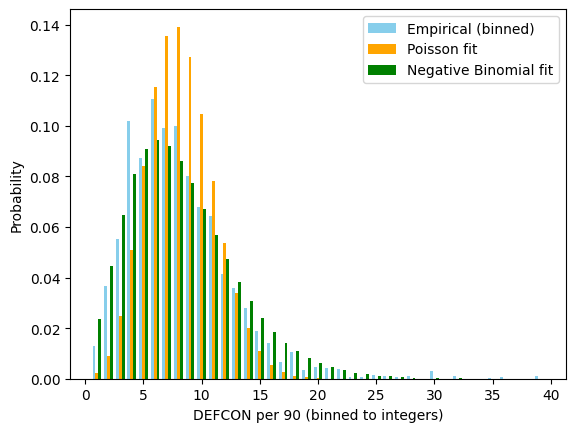

Mean: 8.218, Variance: 21.531
Overdispersion ratio (Var/Mean): 2.620
⚠️ Likely overdispersed → Negative Binomial may fit better.


In [21]:
#Test if defcon_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Mids & Forwards")

# Filter to reasonable samples
data = df[(df['minutes'] > 0)
          & (df['defensive_contribution_per90'] > 0) 
          & (df['defensive_contribution_per90'] < 40)
          & (df['position'].isin(['DEF']))]['defensive_contribution_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean defcon per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('DEFCON per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


GK saves per 90
Estimated λ (mean saves per 90): 3.197


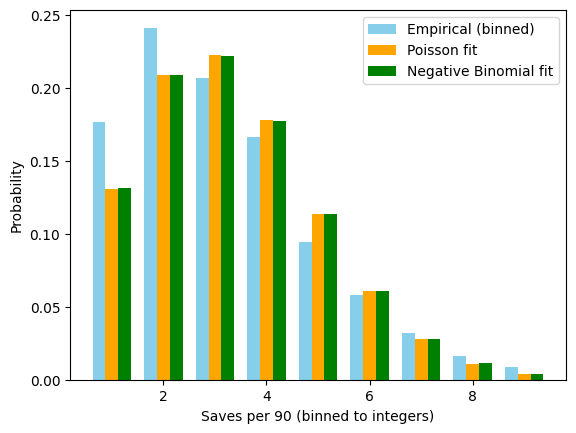

Mean: 3.197, Variance: 3.214
Overdispersion ratio (Var/Mean): 1.005
✅ Poisson assumption looks reasonable.


In [22]:
#Test if saves_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("GK saves per 90")

# Filter to reasonable samples
data = df[#(df['minutes'] > 0)
          (df['saves_per90'] > 0) 
          & (df['saves_per90'] < 10)
          & (df['position'].isin(['GK']))]['saves_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean saves per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Saves per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


In [23]:
#Create the data which the prediction data should be added to
prediction_data = df[(df['season']==20252026)
                     &(df['event']>=current_gw+1)]

In [24]:
def predict_target_vectorized(df, model_dict, col_name):
    preds = []
    
    for pos, model in model_dict.items():
        subset = df[df['position'] == pos]
        if not subset.empty:
            pos_preds = model.predict_new(subset)
            temp = subset.copy()
            temp[col_name] = pos_preds
            preds.append(temp)
    
    if not preds:
        # If no positions matched at all
        return pd.Series(index=df.index, dtype=float)
    
    result = pd.concat(preds)
    
    # Safely align back to original DataFrame
    output = pd.Series(index=df.index, dtype=float)
    output.loc[result.index] = result[col_name]
    return output

In [25]:
target_col_name = 'mins_pred'
mins_model_dict = {'FWD': FWD_mins_predictor, 'MID': MID_mins_predictor, 'DEF': DEF_mins_predictor, 'GK': GK_mins_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_8972\2521843321.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)


count    4056.000000
mean       59.960066
std        20.312625
min        14.619439
25%        42.004832
50%        61.623812
75%        79.157512
max        89.970743
Name: mins_pred, dtype: float64

In [26]:
target_col_name = 'xgp90_pred'
xg_model_dict = {'FWD': FWD_xG_predictor, 'MID': MID_xG_predictor, 'DEF': DEF_xG_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_8972\365369552.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)


count    3783.000000
mean        0.163580
std         0.151233
min         0.029810
25%         0.060919
50%         0.116383
75%         0.210276
max         0.902248
Name: xgp90_pred, dtype: float64

In [27]:
target_col_name = 'xap90_pred'
xA_model_dict = {'FWD': FWD_xA_predictor, 'MID': MID_xA_predictor, 'DEF': DEF_xA_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_8972\4144355699.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)


count    3783.000000
mean        0.104532
std         0.067316
min         0.029148
25%         0.052635
50%         0.081010
75%         0.139277
max         0.356750
Name: xap90_pred, dtype: float64

In [28]:
target_col_name = 'xgcp90_pred'
xGC_model_dict = {'FWD': FWD_xGC_predictor, 'MID': MID_xGC_predictor, 'DEF': DEF_xGC_predictor, 'GK':GK_xGC_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_8972\682035545.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)


count    4056.000000
mean        1.400452
std         0.310983
min         0.438805
25%         1.176747
50%         1.393540
75%         1.590302
max         2.501906
Name: xgcp90_pred, dtype: float64

In [29]:
target_col_name = 'xbpsp90_pred'
bps_model_dict = {'FWD': FWD_bps_predictor, 'MID': MID_bps_predictor, 'DEF': DEF_bps_predictor, 'GK':GK_bps_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_8972\3051138591.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)


count    4056.000000
mean       15.851072
std         3.247010
min         5.874453
25%        13.686732
50%        15.332923
75%        17.537712
max        39.468582
Name: xbpsp90_pred, dtype: float64

                                 OLS Regression Results                                
Dep. Variable:                  bonus   R-squared (uncentered):                   0.448
Model:                            OLS   Adj. R-squared (uncentered):              0.448
Method:                 Least Squares   F-statistic:                          3.511e+04
Date:                Tue, 17 Mar 2026   Prob (F-statistic):                        0.00
Time:                        13:10:35   Log-Likelihood:                         -40730.
No. Observations:               43241   AIC:                                  8.146e+04
Df Residuals:                   43240   BIC:                                  8.147e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

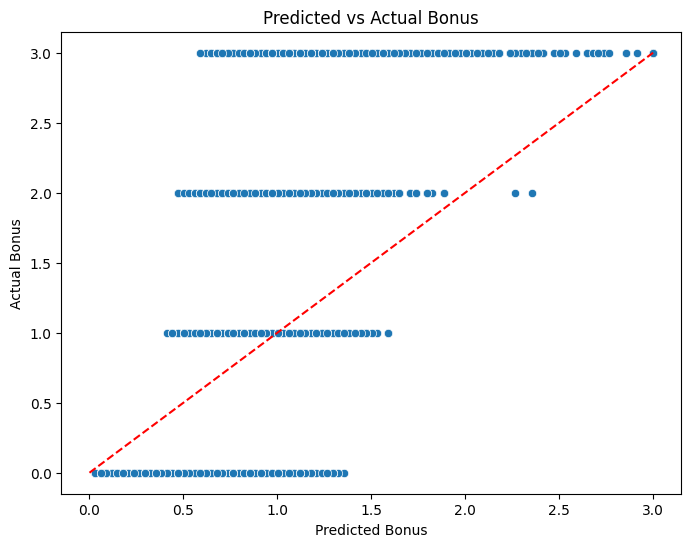

Actual Bonus       0.0       1.0       2.0       3.0
Position                                            
DEF           0.458741  0.228510  1.105691  1.947065
FWD           0.332490  0.196866  1.046155  1.707260
GK            0.488035  0.243825  1.113897  2.006274
GKP                NaN       NaN       NaN       NaN
MID           0.397337  0.244570  1.047815  1.823330


C:\Users\Chris\AppData\Local\Temp\ipykernel_8972\3541705010.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_table = dfb.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))


In [30]:
# Generalize the relationship between bps & bonus points
import statsmodels.formula.api as smf
dfb=df.copy()
filtered = (dfb['minutes']>45) & (dfb['bonus']>=0) & (dfb['bps']>0) & (dfb['position'].isin(['GK','DEF','MID','FWD']))
# df['bonus_sq'] = df['bonus']**2

model = smf.ols('bonus ~ bps -1', data=dfb[filtered]).fit()
print(model.summary())

dfb['bonus_pred'] = model.predict(dfb[filtered])
dfb['bonus_pred'] = np.clip(dfb['bonus_pred'], 0, 3) # clip prediction to 3

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x='bonus_pred', y='bonus', data=dfb)
plt.plot([dfb['bonus'].min(), dfb['bonus'].max()],
         [dfb['bonus'].min(), dfb['bonus'].max()],
         color='red', linestyle='--')  # 45-degree line
plt.xlabel('Predicted Bonus')
plt.ylabel('Actual Bonus')
plt.title('Predicted vs Actual Bonus')
plt.show()

import pandas as pd
import numpy as np

# Function to calculate RMSE
def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

# Group by position and actual bonus, then calculate RMSE
rmse_table = dfb.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))

# Convert to DataFrame
rmse_table = rmse_table.reset_index()
rmse_table.columns = ['Position', 'Actual Bonus', 'RMSE']

pivot_rmse = rmse_table.pivot(index='Position', columns='Actual Bonus', values='RMSE')
print(pivot_rmse)


In [31]:
#Add bonus prediction to data
prediction_data['bonus_pred'] = model.predict(prediction_data)
print("bonus_pred added to prediction data")

bonus_pred added to prediction data


C:\Users\Chris\AppData\Local\Temp\ipykernel_8972\2545047019.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['bonus_pred'] = model.predict(prediction_data)


In [32]:
target_col_name = 'xsavesp90_pred'
saves_model_dict = {'GK':GK_saves_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_8972\803536942.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)


count    273.000000
mean       3.190641
std        0.652676
min        1.371762
25%        2.770454
50%        3.039743
75%        3.498958
max        5.440715
Name: xsavesp90_pred, dtype: float64

In [33]:
target_col_name = 'xdefconp90_pred'
defcon_model_dict = {'FWD': FWD_defcon_predictor, 'MID': MID_defcon_predictor, 'DEF': DEF_defcon_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_8972\2777375241.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)


count    3783.000000
mean        7.940352
std         1.873525
min         2.531717
25%         6.680859
50%         8.037160
75%         9.369850
max        13.835230
Name: xdefconp90_pred, dtype: float64

In [34]:
prediction_data[prediction_data['position']=='MID'].head()[["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]]

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
129354,Ben Winterburn,96.0,45.0,Bournemouth,MID,20252026.0,31.0,Man Utd,1113.283551,35.544123,0.093737,0.158950,1.607024
129357,Ben Winterburn,96.0,45.0,Bournemouth,MID,20252026.0,32.0,Arsenal,1258.933285,36.079043,0.080201,0.128904,1.638833
130035,Adama Traoré Diarra,326.0,51.0,West Ham,MID,20252026.0,31.0,Aston Villa,1125.802842,32.755560,0.136524,0.075367,1.634607
130037,Adama Traoré Diarra,326.0,51.0,West Ham,MID,20252026.0,32.0,Wolves,945.878275,33.529541,0.147954,0.138689,1.191834
130045,Adama Traoré Diarra,326.0,51.0,West Ham,MID,20252026.0,33.0,Crystal Palace,1047.736973,32.755560,0.135129,0.082743,1.693895


In [35]:
prediction_data[
    (prediction_data['event']==current_gw+1)
    &(prediction_data['mins_pred']>0)
    ][["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]].sort_values(by='xgp90_pred',ascending=False
        ).head(10)

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
141804,Marc Guiu Paz,252.0,41.0,Chelsea,FWD,20252026.0,31.0,Everton,1063.420185,47.178774,0.880451,0.226883,1.467546
131252,Arnaud Kalimuendo,696.0,60.0,Nott'm Forest,FWD,20252026.0,31.0,Spurs,967.256888,30.260510,0.825158,0.280739,1.728565
132427,Callum Marshall,626.0,43.0,West Ham,FWD,20252026.0,31.0,Aston Villa,1125.802842,43.760926,0.823600,0.216667,2.204929
132831,Chris Wood,525.0,71.0,Nott'm Forest,FWD,20252026.0,31.0,Spurs,967.256888,33.156180,0.791093,0.283682,1.659702
144023,Niclas Füllkrug,625.0,56.0,West Ham,FWD,20252026.0,31.0,Aston Villa,1125.802842,41.526562,0.772446,0.223502,2.293996
130177,Alexander Isak,499.0,103.0,Liverpool,FWD,20252026.0,31.0,Brighton,1080.364275,34.900219,0.738155,0.323795,1.648191
147277,Stefanos Tzimas,180.0,52.0,Brighton,FWD,20252026.0,31.0,Liverpool,1163.843221,31.985142,0.728033,0.237322,1.673927
148759,William Osula,500.0,54.0,Newcastle,FWD,20252026.0,31.0,Sunderland,1028.600710,19.771583,0.666989,0.086393,1.605504
138983,Jonah Kusi-Asare,737.0,45.0,Fulham,FWD,20252026.0,31.0,Burnley,891.228204,33.544614,0.613077,0.324967,1.888545
132793,Charalampos Kostoulas,181.0,48.0,Brighton,FWD,20252026.0,31.0,Liverpool,1163.843221,20.406311,0.604311,0.231078,1.630543


In [36]:
import pandas as pd
from scipy.stats import nbinom

def calculate_negbinom_parameters(position_list, df):

    # 1. Calculate mean and variance
    filtered = (df['minutes'] > 0) & (df['defensive_contribution_per90'] > 0) & (df['defensive_contribution_per90'] < 40) & (df['position'].isin(position_list))
    mean = df[filtered]['defensive_contribution_per90'].mean()
    variance = df[filtered]['defensive_contribution_per90'].var()
    # r = number of successes
    r = (mean**2) / (variance - mean)
    # p = success probability
    p = r / (r + mean)
    return r,p

In [37]:
from scipy.stats import poisson
import numpy as np

def expected_score(mu, max_events=10, rule=None, points_per_n=None, points_value=None):
    """
    Calculate the expected score given an average event rate (mu)
    using a Poisson model.

    Parameters
    ----------
    mu : float
        Expected number of events (e.g., goals conceded, shots saved).
    max_events : int
        Maximum number of discrete events to sum over.
    rule : callable, optional
        Function that maps event count -> points. Example: lambda k: -np.floor(k / 2)
    points_per_n : int, optional
        For simple rules: number of events required for one point (e.g. 3 shots saved = 1 pt)
    points_value : float, optional
        Value of that one point (e.g. +1 for shots saved, -1 for goals conceded)

    Returns
    -------
    float
        Expected points based on Poisson-distributed event counts.
    """
    array = np.arange(0, max_events + 1)
    probs = poisson.pmf(array, mu)

    if rule is not None:
        scores = np.array([rule(k) for k in array])
    elif points_per_n is not None and points_value is not None:
        # General simple rule: 1 point_value for every n events
        scores = np.floor(array / points_per_n) * points_value
    else:
        raise ValueError("You must provide either a rule function or both points_per_n and points_value.")

    return np.sum(scores * probs)


In [38]:
from scipy.stats import norm
import numpy as np

scoring_dict = {
    "FWD": {'xgp90_pred': 4, 'xap90_pred': 3, 'xgcp90_pred': 0, 'xgc_ss':0, 'defcon':2},
    "MID": {'xgp90_pred': 5, 'xap90_pred': 3, 'xgcp90_pred': 1, 'xgc_ss':0, 'defcon':2},
    "DEF": {'xgp90_pred': 6, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2},
    "GK":  {'xgp90_pred': 10, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2}
}

def scoring(x, scoring_dict, points_type, negbinom_rp_dict=None):
    mins_factor = x['mins_pred']/90
    if points_type == 'mins':
        if pd.isna(x['mins_pred']):
            return 0
        elif x['mins_pred'] > 0:
            return 1 + 1 / (1 + np.exp(-(x['mins_pred'] - 60) / 10)) #smooth logistic approximation from 1 to 2 points, 10 is a scale factor
        
    if points_type == 'goals':
        goals_points = mins_factor * x['xgp90_pred'] * scoring_dict[x['position']]['xgp90_pred']
        return goals_points
    if points_type == 'assists':
        assist_points = mins_factor * x['xap90_pred'] * scoring_dict[x['position']]['xap90_pred']
        return assist_points
    if points_type == 'clean_sheets':
        p_less_than_1 = poisson.cdf(0, mu=x['xgcp90_pred'])
        cs_points = p_less_than_1 * scoring_dict[x['position']]['xgcp90_pred']
        return cs_points
    
    if points_type == 'shots_saved': 
        if x['position'] == 'GK':
            saves_points = expected_score(mu=x['xsavesp90_pred'],  # expected shots saved per 90
                                   max_events=15,
                                   points_per_n=3, #for every 3 shots saved
                                   points_value=1) #scores 1 point
            return saves_points
        else:
            return 0
        
    if points_type == 'goals_conceded':
        if x['position'] in ['DEF','GK']:
            gc_points = expected_score(mu=x['xgcp90_pred'], 
                                   max_events=10, 
                                   points_per_n=2, #for every 2 goals conceded 
                                   points_value=-1) #scores -1 points 
            return gc_points
        else:
            return 0

    if points_type == 'defcon':
        pos = x['position']
        if pos in ['MID','FWD']:
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 12
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        elif pos == 'DEF':
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 10
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        else: return 0

    if points_type == 'bonus':
        return x['xbpsp90_pred']*0.0294 # ols regression coefficient

prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
prediction_data['xpoints_assists'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='assists'), axis=1)
prediction_data['xpoints_clean_sheets'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='clean_sheets'), axis=1)

prediction_data['xpoints_shots_saved'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='shots_saved'), axis=1)
prediction_data['xpoints_goals_conceded'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals_conceded'), axis=1)

def_r,def_p = calculate_negbinom_parameters(['DEF'], df)
mid_r,mid_p = calculate_negbinom_parameters(['MID'], df)
fwd_r,fwd_p = calculate_negbinom_parameters(['FWD'], df)
rp_dict = {'DEF':{'r':def_r,'p':def_p},'MID':{'r':mid_r,'p':mid_p},'FWD':{'r':fwd_r,'p':fwd_p}}
prediction_data['xpoints_defcon'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='defcon', negbinom_rp_dict=rp_dict), axis=1)
prediction_data['xpoints_bonus'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='bonus'), axis=1)

prediction_data['xpoints'] = prediction_data[['xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets',
                                              'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus']].sum(axis=1, skipna=True)

C:\Users\Chris\AppData\Local\Temp\ipykernel_8972\3158721815.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykernel_8972\3158721815.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykernel_

In [39]:
predictions = prediction_data[['player_name_id', 'team_name','team_elo','element','position','opp_team_name','opp_team_elo', 'season', 'value', 'event',
                       'mins_pred', 'xgp90_pred', 'xap90_pred', 'xgcp90_pred',
                       'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets','xpoints_shots_saved',
                       'xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                       'xpoints']]

In [40]:
table_name = "predictions"
if __name__ == "__main__":
    db_creator.create_staging_table_then_insert_data(table_name, data=predictions)
    preds = db_creator.table_to_df(table_name=table_name)
    print(preds.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4056 entries, 0 to 4055
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   player_name_id          4056 non-null   object 
 1   team_name               4056 non-null   object 
 2   team_elo                4056 non-null   float64
 3   element                 4056 non-null   float64
 4   position                4056 non-null   object 
 5   opp_team_name           4056 non-null   object 
 6   opp_team_elo            4056 non-null   float64
 7   season                  4056 non-null   float64
 8   value                   4056 non-null   float64
 9   event                   4056 non-null   float64
 10  mins_pred               4056 non-null   float64
 11  xgp90_pred              3783 non-null   float64
 12  xap90_pred              3783 non-null   float64
 13  xgcp90_pred             4056 non-null   float64
 14  xpoints_mins            4056 non-null   

In [41]:
# Add new columns to the xPoints table
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS in_any_team INTEGER DEFAULT 0,
    ADD COLUMN IF NOT EXISTS in_my_team INTEGER DEFAULT 0
""")

In [42]:
my_name = "Christopher Harris"

# Get the player lists
view = db_creator.run_sql(f"""
    WITH 
    current_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gw}
    ),
    my_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gw}
        AND member = '{my_name}'
    )
    SELECT * FROM my_players
""")

# Update the flags
db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_any_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gw}
    )
""")

db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_my_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gw}
        AND member = '{my_name}'
    )
""")

In [43]:
print(f"Gameweek {current_gw+1} Predictions")
prediction_data[
    prediction_data['event']==current_gw+1
][["player_name_id","element",'event',"value","team_name","position","opp_team_name","opp_team_elo"
   ,'mins_pred', 'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets', 
   'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
   'xpoints'
   ]].sort_values(by='xpoints',ascending=False
    ).head(10)

Gameweek 31 Predictions


,player_name_id,element,event,value,team_name,position,opp_team_name,opp_team_elo,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
132234,Bruno Borges Fernandes,449.0,31.0,101.0,Man Utd,MID,Bournemouth,1066.816076,80.882258,1.889754,0.914698,0.839211,0.237426,0.0,0.000000,0.507163,0.688485,5.076736
135195,Ezri Konsa Ngoyo,38.0,31.0,44.0,Aston Villa,DEF,West Ham,993.767441,80.679522,1.887749,0.277001,0.135611,1.797255,0.0,-0.200488,0.542754,0.597802,5.037684
141280,Lucas Digne,37.0,31.0,45.0,Aston Villa,DEF,West Ham,993.767441,73.455805,1.793406,0.244005,0.189354,1.867311,0.0,-0.185380,0.542754,0.558824,5.010276
142803,Matty Cash,36.0,31.0,48.0,Aston Villa,DEF,West Ham,993.767441,78.970445,1.869557,0.212116,0.160463,1.821662,0.0,-0.195123,0.542754,0.536773,4.948201
130271,Alex Iwobi,324.0,31.0,64.0,Fulham,MID,Burnley,891.228204,86.286582,1.932683,0.782922,0.617036,0.388855,0.0,0.000000,0.507163,0.689807,4.918466
136499,Harry Wilson,329.0,31.0,60.0,Fulham,MID,Burnley,891.228204,84.145890,1.917933,0.960301,0.485011,0.381567,0.0,0.000000,0.507163,0.623408,4.875383
130439,Alexis Mac Allister,386.0,31.0,63.0,Liverpool,MID,Brighton,1080.364275,84.608577,1.921352,1.056111,0.484302,0.268622,0.0,0.000000,0.507163,0.588198,4.825747
148335,Tyrone Mings,40.0,31.0,43.0,Aston Villa,DEF,West Ham,993.767441,77.159836,1.847611,0.230369,0.177644,1.597021,0.0,-0.248928,0.542754,0.618859,4.765329
143653,Morgan Gibbs-White,515.0,31.0,73.0,Nott'm Forest,MID,Spurs,967.256888,81.698025,1.897505,1.023916,0.439616,0.378448,0.0,0.000000,0.507163,0.516838,4.763485
138447,Joachim Andersen,317.0,31.0,45.0,Fulham,DEF,Burnley,891.228204,80.395141,1.884884,0.214946,0.119602,1.660988,0.0,-0.232548,0.542754,0.569851,4.760478


In [44]:
print(f"Next 5 GWs: GW{current_gw+1} - GW{current_gw+5}")
next_5_gws_filter = (prediction_data['event']>=current_gw)&(prediction_data['event']<=current_gw+5)
prediction_data[next_5_gws_filter].groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Next 5 GWs: GW31 - GW35


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
380,Nico O'Reilly,317.610009,7.496978,7.575066,0.711387,6.323801,0.0,-1.045138,2.171017,2.332219,25.565331
64,Bruno Borges Fernandes,404.411289,9.448768,4.636890,3.588753,1.317776,0.0,0.000000,2.535813,3.500985,25.028985
144,Ezri Konsa Ngoyo,403.397609,9.438745,1.385273,0.676755,8.173960,0.0,-1.215438,2.713771,2.940761,24.113828
15,Alexis Mac Allister,423.042884,9.606759,5.268739,2.425169,1.310586,0.0,0.000000,2.535813,2.910025,24.057092
304,Lucas Digne,367.346169,8.968129,1.222079,0.940793,8.182782,0.0,-1.230817,2.713771,2.792794,23.589532
364,Morgan Gibbs-White,407.898901,9.481956,5.168677,2.116555,1.517435,0.0,0.000000,2.535813,2.611930,23.432367
91,Crysencio Summerville,419.161920,9.577701,4.772467,1.999505,1.418730,0.0,0.000000,2.535813,3.053953,23.358169
119,Dominik Szoboszlai,432.081295,9.667465,4.398537,2.738726,1.137770,0.0,0.000000,2.535813,2.811340,23.289651
269,Justin Kluivert,267.660691,6.719379,8.605033,2.081674,0.970141,0.0,0.000000,2.535813,2.201263,23.113303
86,Cole Palmer,397.316676,9.375229,4.707926,2.376156,1.277652,0.0,0.000000,2.535813,2.820762,23.093539


In [45]:
print("Rest of Season Predictions")
prediction_data.groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 
                                           'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Rest of Season Predictions


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
380,Nico O'Reilly,555.038978,13.111428,13.125047,1.289039,10.701327,0.0,-1.907675,3.799280,4.179136,44.297582
64,Bruno Borges Fernandes,647.058062,15.118028,7.400847,5.828380,2.166744,0.0,0.000000,4.057302,5.748298,40.319599
15,Alexis Mac Allister,676.868614,15.370815,8.343818,3.665894,1.963276,0.0,0.000000,4.057302,4.561416,37.962521
267,Jurriën Timber,598.487655,13.492874,3.637864,2.404637,11.913078,0.0,-1.588249,3.799280,3.937899,37.597384
86,Cole Palmer,635.592608,14.999111,7.601921,3.839640,2.146690,0.0,0.000000,4.057302,4.582230,37.226894
364,Morgan Gibbs-White,652.992977,15.174471,8.321281,3.287773,2.194581,0.0,0.000000,4.057302,4.130219,37.165626
91,Crysencio Summerville,670.307067,15.321559,7.571521,3.121968,2.197159,0.0,0.000000,4.057302,4.851406,37.120915
269,Justin Kluivert,428.431749,10.754697,13.711939,3.439723,1.501495,0.0,0.000000,4.057302,3.441517,36.906673
119,Dominik Szoboszlai,691.330071,15.467944,6.942903,4.160563,1.715892,0.0,0.000000,4.057302,4.423901,36.768504
335,Matheus Santos Carneiro da Cunha,678.803930,15.384696,7.583853,2.938365,2.269166,0.0,0.000000,4.057302,4.185790,36.419172


In [46]:
from datetime import datetime

# Add the columns
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS prediction_timestamp TIMESTAMP,
    ADD COLUMN IF NOT EXISTS prediction_gameweek INTEGER;
""")

# Update ALL existing rows with current timestamp and gameweek
db_creator.execute_sql("""
    UPDATE predictions
    SET prediction_timestamp = :timestamp,
        prediction_gameweek = :gameweek;
""", params={
    'timestamp': datetime.now(),
    'gameweek': current_gw
})

In [47]:
# ## Reset predictions table

# db_creator.execute_sql("""
#     DROP TABLE IF EXISTS predictions_allgws
# """)

In [48]:
# Create predictions_allgws if it doesn't exist
db_creator.execute_sql("""
    CREATE TABLE IF NOT EXISTS predictions_allgws AS
    SELECT p.*,
            -- pg.player_name_id, pg.team_name, pg.team_elo, pg.element, pg.position, pg.opp_team_name, pg.opp_team_elo, pg.value -- these are in both tables
            pg.fixture, pg.total_points
            
    FROM predictions p
    LEFT JOIN playergw pg 
        ON p.player_name_id = pg.player_name_id 
        AND p.event = pg.event
        AND p.season = pg.season
    WHERE 1=0;  -- Empty table with correct schema
""")

In [49]:
# Step 1: Insert new predictions with current timestamp
# This will create NEW rows even for gameweeks that already have predictions
db_creator.execute_sql("""
INSERT INTO predictions_allgws (
    player_name_id, team_name, team_elo, element, position, opp_team_name, opp_team_elo, value, 
    event, season, xpoints, 
    prediction_timestamp, prediction_gameweek,
    fixture, total_points
)
SELECT 
    p.player_name_id, p.team_name, p.team_elo, p.element, p.position, p.opp_team_name, 
    p.opp_team_elo, p.value, p.event, p.season, p.xpoints, 
    p.prediction_timestamp, p.prediction_gameweek,
    pg.fixture, pg.total_points
FROM predictions p
LEFT JOIN playergw pg 
    ON p.player_name_id = pg.player_name_id 
    AND p.event = pg.event 
    AND p.season = pg.season;
""")

print(f"Successfully added {db_creator.run_sql('SELECT COUNT(*) FROM predictions').iloc[0,0]} new predictions to predictions_allgws")

Successfully added 4056 new predictions to predictions_allgws


In [50]:
view = db_creator.table_to_df('predictions_allgws')
future_filter = (
    view['prediction_gameweek']==current_gw) & (
    view['event']==current_gw+1) & (
    view['player_name_id']=='Erling Haaland')
view[['player_name_id','event','season','total_points']][future_filter].head()

,player_name_id,event,season,total_points


In [51]:
view = db_creator.table_to_df('playergw')
future_filter = (view['season']==20252026)&(view['event']>=13)&(view['player_name_id']=='Erling Haaland')
view[['player_name_id','event','season','total_points','minutes']][future_filter].head(10)

,player_name_id,event,season,total_points,minutes
183352,Erling Haaland,13.0,20252026.0,2.0,90.0
183353,Erling Haaland,14.0,20252026.0,14.0,90.0
183354,Erling Haaland,15.0,20252026.0,2.0,68.0
183355,Erling Haaland,16.0,20252026.0,13.0,90.0
183356,Erling Haaland,17.0,20252026.0,16.0,90.0
183357,Erling Haaland,18.0,20252026.0,2.0,90.0
183358,Erling Haaland,19.0,20252026.0,2.0,90.0
183359,Erling Haaland,20.0,20252026.0,2.0,90.0
183360,Erling Haaland,21.0,20252026.0,6.0,90.0
183361,Erling Haaland,22.0,20252026.0,2.0,79.0


In [52]:
view = db_creator.table_to_df('predictions_allgws')
view[['player_name_id','prediction_timestamp','event','xpoints','total_points']][
    (view['season']==20252026)&(
    view['event']>=20)&(view['player_name_id']=='Erling Haaland')].sort_values(by='event')

,player_name_id,prediction_timestamp,event,xpoints,total_points
1615,Erling Haaland,2026-01-05 18:33:33.065519,21.0,5.628327,6.0
13463,Erling Haaland,2026-01-05 18:33:33.065519,22.0,5.571476,2.0
13479,Erling Haaland,2026-01-05 18:33:33.065519,23.0,7.368988,1.0
13464,Erling Haaland,2026-01-05 18:33:33.065519,24.0,5.915376,NaN
5663,Erling Haaland,2026-01-26 14:27:00.627006,24.0,4.148815,NaN
...,...,...,...,...,...
82767,Erling Haaland,2026-02-24 10:14:37.233826,38.0,4.475827,NaN
92237,Erling Haaland,2026-03-15 09:50:14.619059,38.0,4.089695,NaN
71670,Erling Haaland,2026-02-22 11:15:02.719357,38.0,4.363917,NaN
96277,Erling Haaland,2026-03-16 11:42:07.478367,38.0,3.995860,NaN


In [53]:
# Get the data from the predictions table
df_preds = db_creator.table_to_df('predictions_allgws')

# Remove rows where actual_points is missing
gw_filter=(df_preds['prediction_gameweek']>=13)&(
            df_preds['event']>=current_gw)&(
                df_preds['event']<=current_gw+5)&(
            df_preds['season']==20252026)#&(
            #df_preds['player_name_id']=='Erling Haaland')
df_complete = df_preds[gw_filter]

df_complete.pivot_table(index=['prediction_timestamp','prediction_gameweek','season','event'], values=['xpoints','total_points'])

xpoints
prediction_timestamp       prediction_gameweek season     event          
2026-01-05 18:33:33.065519 20                  20252026.0 30.0   3.432445
                                                          31.0   3.432435
                                                          32.0   3.417936
                                                          33.0   3.403198
                                                          34.0   3.418776
...                                                                   ...
2026-03-17 13:10:43.568742 30                  20252026.0 31.0   3.426979
                                                          32.0   3.441825
                                                          33.0   3.431403
                                                          34.0   3.451453
                                                          35.0   3.448152

[123 rows x 1 columns]

In [54]:
#Future GWs should show more than one row here when more predictions are added...
df_complete.pivot_table(index='prediction_timestamp',values='player_name_id',aggfunc='count',dropna=False)

,player_name_id
prediction_timestamp,
2026-01-05 18:33:33.065519,2910
2026-01-07 16:29:20.849190,12
2026-01-08 16:44:49.940956,12
2026-01-22 16:59:38.976316,18
2026-01-25 11:24:25.347489,6
2026-01-26 14:27:00.627006,2970
2026-01-27 11:00:04.422834,2976
2026-02-01 11:57:12.353330,2988
2026-02-02 13:38:00.840050,3006


In [55]:
df_complete.columns.to_list()

['player_name_id',
 'team_name',
 'team_elo',
 'element',
 'position',
 'opp_team_name',
 'opp_team_elo',
 'season',
 'value',
 'event',
 'mins_pred',
 'xgp90_pred',
 'xap90_pred',
 'xgcp90_pred',
 'xpoints_mins',
 'xpoints_goals',
 'xpoints_assists',
 'xpoints_clean_sheets',
 'xpoints_shots_saved',
 'xpoints_goals_conceded',
 'xpoints_defcon',
 'xpoints_bonus',
 'xpoints',
 'in_any_team',
 'in_my_team',
 'prediction_timestamp',
 'prediction_gameweek',
 'total_points',
 'fixture']

In [61]:
filtered = (df_complete['player_name_id'] == 'Bukayo Saka')&(
    df_complete['season']==20252026) & (df_complete['event']==31)
df_complete[filtered][['prediction_timestamp','prediction_gameweek','season','event','xpoints','total_points']].sort_values(by='prediction_timestamp')

,prediction_timestamp,prediction_gameweek,season,event,xpoints,total_points
8764,2026-01-05 18:33:33.065519,20,20252026.0,31.0,5.287336,NaN
16218,2026-01-26 14:27:00.627006,23,20252026.0,31.0,4.560289,NaN
23107,2026-01-27 11:00:04.422834,23,20252026.0,31.0,4.538511,NaN
30091,2026-02-01 11:57:12.353330,24,20252026.0,31.0,4.542477,NaN
37092,2026-02-02 13:38:00.840050,24,20252026.0,31.0,4.492280,NaN
44104,2026-02-03 14:41:19.430154,24,20252026.0,31.0,4.346994,NaN


In [57]:
filtered = df_complete['prediction_gameweek']==21
df_complete[filtered][['prediction_timestamp','player_name_id','event']].describe()

,prediction_timestamp,event
count,24,24.000000
mean,2026-01-08 04:37:05.395073024,32.500000
min,2026-01-07 16:29:20.849190,30.000000
25%,2026-01-07 16:29:20.849189888,31.000000
50%,2026-01-08 04:37:05.395073024,32.500000
75%,2026-01-08 16:44:49.940955904,34.000000
max,2026-01-08 16:44:49.940956,35.000000
std,NaN,1.744557


In [58]:
# # Create the plot
# plt.figure(figsize=(10, 8))
# sns.scatterplot(data=df_complete, x='xpoints', y='total_points', alpha=0.6)

# # Add a diagonal reference line (perfect predictions)
# max_val = max(df_complete['xpoints'].max(), df_complete['total_points'].max())
# plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction', linewidth=2)

# # Add regression line showing actual correlation
# from scipy.stats import linregress
# slope, intercept, r_value, p_value, std_err = linregress(df_complete['xpoints'], df_complete['total_points'])
# x_line = np.array([df_complete['xpoints'].min(), df_complete['xpoints'].max()])
# y_line = slope * x_line + intercept
# plt.plot(x_line, y_line, 'g-', label=f'Best fit (y={slope:.2f}x+{intercept:.2f})', linewidth=2)

# print(f"Correlation: {df_complete['xpoints'].corr(df_complete['total_points']):.3f}")
# print(f"Mean Absolute Error: {(df_complete['xpoints'] - df_complete['total_points']).abs().mean():.3f}")
# print(f"Root Mean Squared Error: {((df_complete['xpoints'] - df_complete['total_points'])**2).mean()**0.5:.3f}")

# plt.xlabel('Predicted Points (xPoints)', fontsize=12)
# plt.ylabel('Actual Points', fontsize=12)
# plt.title(f'Predicted vs Actual Points in GW{current_gw}', fontsize=14, fontweight='bold')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

In [59]:
finish=time.perf_counter()
print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
#10/11/25: Finished in 8.91 minute(s)

Finished in 33.07 minute(s)


In [60]:
# Notification when file has finished running
from plyer import notification

notification.notify(
    title='Script Complete',
    message='Your file has finished running!',
    app_name='Jupyter Notebook',
    timeout=20  # notification stays for 20 seconds
)